In [3]:
import numpy as np
import pandas as pd
import pickle 
from os import path

from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, LabelEncoder, MinMaxScaler, OneHotEncoder)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import Normalizer, MaxAbsScaler , RobustScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel

import matplotlib.pyplot as plt
import seaborn as sns

import os


In [4]:
file_path = r"D:\cicids2017\merged.csv"
df = pd.read_csv(file_path)

print("원본 데이터 크기:", df.shape)
df.head()

원본 데이터 크기: (543734, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,115550790,31,33,318,38380,318,0,10.258065,57.114486,...,32,29534.636364,20922.826407,92617,22941,1.002161e+07,8209.967001,10025078,9998039,BENIGN
1,443,5292756,6,4,611,168,517,0,101.833333,204.305082,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2,21,3,2,0,14,0,14,0,7.000000,9.899495,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,FTP-Patator
3,54045,41,1,1,2,6,2,2,2.000000,0.000000,...,24,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,PortScan
4,80,1023,2,0,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DoS Hulk


In [5]:
df.info()
#coulm 요약

"""
1. 기본 연결 정보

Destination Port: 목적지 포트 번호.

Flow Duration: 이 연결이 얼마나 오래 지속됐는지 나타낸다.
단위는 보통 마이크로초 계열로 쓰이는 경우가 많다.
정상 연결보다 공격 연결이 훨씬 짧거나 길 수 있다.

2. 패킷 개수 관련
Total Fwd Packets

송신 방향(Forward) 패킷 총 개수

Total Backward Packets

응답 방향(Backward) 패킷 총 개수

Subflow Fwd Packets

서브플로우 기준 송신 패킷 수

Subflow Bwd Packets

서브플로우 기준 수신 패킷 수

이런 값들은 공격일 때 패킷 수가 비정상적으로 많거나 적게 나타날 수 있다.
예를 들어 DDoS는 짧은 시간에 많은 패킷이 몰릴 수 있다.

3. 바이트/길이 관련
Total Length of Fwd Packets

송신 방향 패킷들의 총 바이트 길이

Total Length of Bwd Packets

수신 방향 패킷들의 총 바이트 길이

Fwd Packet Length Max / Min / Mean / Std

송신 패킷 길이의 최대/최소/평균/표준편차

Bwd Packet Length Max / Min / Mean / Std

수신 패킷 길이의 최대/최소/평균/표준편차

Min Packet Length

전체 패킷 중 최소 길이

Max Packet Length

전체 패킷 중 최대 길이

Packet Length Mean / Std / Variance

전체 패킷 길이 통계

Average Packet Size

평균 패킷 크기

Avg Fwd Segment Size

송신 세그먼트 평균 크기

Avg Bwd Segment Size

수신 세그먼트 평균 크기

이런 컬럼은 트래픽 “모양”을 설명한다.
정상 웹 트래픽과 스캔/봇/브루트포스는 패킷 크기 패턴이 많이 다를 수 있다.

4. 속도 관련
Flow Bytes/s

초당 바이트 수

Flow Packets/s

초당 패킷 수

Fwd Packets/s

송신 방향 초당 패킷 수

Bwd Packets/s

수신 방향 초당 패킷 수

이건 매우 중요하다.
DDoS, Hulk 같은 공격은 짧은 시간에 몰아치는 성향이 있어서 이런 값이 강한 특징이 된다.

다만 지금 파일에서는 이 컬럼들에 inf 가 있어서 클리닝 필수다.

5. IAT(Inter-Arrival Time, 도착 간격) 관련

IAT는 패킷과 패킷 사이 시간 간격이다.

전체 플로우 기준
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
송신 방향
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
수신 방향
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min

이 값들은 공격 트래픽의 리듬을 보여준다.
예를 들어 자동화 공격은 간격이 매우 규칙적일 수 있고, 정상 사용자 트래픽은 더 불규칙할 수 있다.

6. TCP 플래그 관련
방향별 플래그
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
전체 플래그 카운트
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count

이건 TCP 연결의 상태를 보여준다.

예를 들어:

SYN 많음 → 연결 시도 성향
RST 많음 → 비정상 종료/거부
ACK 많음 → 정상 응답 패턴

특히 PortScan, SYN flood 계열 을 구분할 때 중요할 수 있다.

7. 헤더/윈도우/세그먼트 관련
Fwd Header Length

송신 패킷 헤더 길이 합 또는 통계

Bwd Header Length

수신 패킷 헤더 길이

Fwd Header Length.1

Fwd Header Length 와 동일한 중복 컬럼

Init_Win_bytes_forward

초기 송신 윈도우 크기

Init_Win_bytes_backward

초기 수신 윈도우 크기

min_seg_size_forward

송신 최소 세그먼트 크기

act_data_pkt_fwd

실제 데이터가 포함된 송신 패킷 수

이런 값들은 TCP 동작 특성을 반영한다.
공격 툴이 만든 트래픽은 정상 OS/브라우저의 TCP 특성과 다를 수 있다.

8. 비율/방향성 관련
Down/Up Ratio

다운로드 대 업로드 비율
즉 수신과 송신의 비대칭 정도를 본다.

정상 웹 트래픽은 응답이 큰 편이라 비율이 한쪽으로 쏠릴 수 있고,
스캔/브루트포스는 다른 패턴을 보일 수 있다.

9. Bulk 전송 관련
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate

이건 대용량 묶음 전송 특성을 나타낸다.
다만 CICIDS에서는 이 값들이 0이 많거나 정보량이 낮은 경우도 많다.
EDA 보고 제거 여부를 판단해도 된다.

10. Active / Idle 관련
Active 구간
Active Mean
Active Std
Active Max
Active Min
Idle 구간
Idle Mean
Idle Std
Idle Max
Idle Min

이건 플로우가 실제로 활발하게 전송 중인 시간과, 쉬고 있는 시간의 통계다.
공격 트래픽은 정상 사용자 행동보다 훨씬 기계적이라서 이 특성이 잘 먹힐 수 있다.

11. 라벨
Label

"""


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543734 entries, 0 to 543733
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             543734 non-null  int64  
 1   Flow Duration                543734 non-null  int64  
 2   Total Fwd Packets            543734 non-null  int64  
 3   Total Backward Packets       543734 non-null  int64  
 4   Total Length of Fwd Packets  543734 non-null  int64  
 5   Total Length of Bwd Packets  543734 non-null  int64  
 6   Fwd Packet Length Max        543734 non-null  int64  
 7   Fwd Packet Length Min        543734 non-null  int64  
 8   Fwd Packet Length Mean       543734 non-null  float64
 9   Fwd Packet Length Std        543734 non-null  float64
 10  Bwd Packet Length Max        543734 non-null  int64  
 11  Bwd Packet Length Min        543734 non-null  int64  
 12  Bwd Packet Length Mean       543734 non-null  float64
 13 

'\n1. 기본 연결 정보\n\nDestination Port: 목적지 포트 번호.\n\nFlow Duration: 이 연결이 얼마나 오래 지속됐는지 나타낸다.\n단위는 보통 마이크로초 계열로 쓰이는 경우가 많다.\n정상 연결보다 공격 연결이 훨씬 짧거나 길 수 있다.\n\n2. 패킷 개수 관련\nTotal Fwd Packets\n\n송신 방향(Forward) 패킷 총 개수\n\nTotal Backward Packets\n\n응답 방향(Backward) 패킷 총 개수\n\nSubflow Fwd Packets\n\n서브플로우 기준 송신 패킷 수\n\nSubflow Bwd Packets\n\n서브플로우 기준 수신 패킷 수\n\n이런 값들은 공격일 때 패킷 수가 비정상적으로 많거나 적게 나타날 수 있다.\n예를 들어 DDoS는 짧은 시간에 많은 패킷이 몰릴 수 있다.\n\n3. 바이트/길이 관련\nTotal Length of Fwd Packets\n\n송신 방향 패킷들의 총 바이트 길이\n\nTotal Length of Bwd Packets\n\n수신 방향 패킷들의 총 바이트 길이\n\nFwd Packet Length Max / Min / Mean / Std\n\n송신 패킷 길이의 최대/최소/평균/표준편차\n\nBwd Packet Length Max / Min / Mean / Std\n\n수신 패킷 길이의 최대/최소/평균/표준편차\n\nMin Packet Length\n\n전체 패킷 중 최소 길이\n\nMax Packet Length\n\n전체 패킷 중 최대 길이\n\nPacket Length Mean / Std / Variance\n\n전체 패킷 길이 통계\n\nAverage Packet Size\n\n평균 패킷 크기\n\nAvg Fwd Segment Size\n\n송신 세그먼트 평균 크기\n\nAvg Bwd Segment Size\n\n수신 세그먼트 평균 크기\n\n이런 컬럼은 트래픽 “모양”을 설명한다.\n정상 웹 트래픽과 스캔/봇/브루트포스는 패킷 크기 패턴

In [6]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,543734.000000,5.437340e+05,543734.000000,543734.000000,5.437340e+05,5.437340e+05,543734.000000,543734.000000,543734.000000,543734.000000,...,543734.000000,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05,5.437340e+05
mean,5652.103023,1.937605e+07,6.108893,5.972426,3.002415e+02,8.834826e+03,131.321223,9.436953,32.996821,44.863896,...,3.581683,-1.361625e+03,1.197564e+05,3.555852e+04,1.618091e+05,9.632056e+04,1.487270e+07,1.187951e+06,1.580700e+07,1.400411e+07
std,15161.228012,3.652159e+07,488.147584,648.833440,3.592328e+03,1.440436e+06,334.212862,48.653727,84.198696,107.928364,...,467.035301,3.412800e+05,7.627244e+05,3.991436e+05,9.949774e+05,7.030387e+05,3.179360e+07,7.222734e+06,3.295477e+07,3.150256e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,6.600000e+01,1.000000,1.000000,2.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,6.069900e+04,2.000000,1.000000,3.000000e+01,8.600000e+01,20.000000,0.000000,8.666667,0.000000,...,1.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,465.000000,9.233649e+06,5.000000,5.000000,1.660000e+02,1.159500e+04,66.000000,6.000000,46.000000,26.162951,...,2.000000,3.200000e+01,4.000000e+00,0.000000e+00,4.000000e+00,4.000000e+00,6.099841e+06,0.000000e+00,6.101830e+06,5.773852e+06
max,65534.000000,1.200000e+08,214125.000000,283900.000000,1.267983e+06,6.296006e+08,23360.000000,2065.000000,5940.857143,7049.469004,...,204290.000000,1.260000e+02,1.016597e+08,2.960904e+07,1.016597e+08,1.016597e+08,1.200000e+08,7.514502e+07,1.200000e+08,1.200000e+08


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,543734.0,5.652103e+03,1.516123e+04,0.0,80.0,80.0,465.00,6.553400e+04
Flow Duration,543734.0,1.937605e+07,3.652159e+07,-1.0,66.0,60699.0,9233649.25,1.200000e+08
Total Fwd Packets,543734.0,6.108893e+00,4.881476e+02,1.0,1.0,2.0,5.00,2.141250e+05
Total Backward Packets,543734.0,5.972426e+00,6.488334e+02,0.0,1.0,1.0,5.00,2.839000e+05
Total Length of Fwd Packets,543734.0,3.002415e+02,3.592328e+03,0.0,2.0,30.0,166.00,1.267983e+06
...,...,...,...,...,...,...,...,...
Active Min,543734.0,9.632056e+04,7.030387e+05,0.0,0.0,0.0,4.00,1.016597e+08
Idle Mean,543734.0,1.487270e+07,3.179360e+07,0.0,0.0,0.0,6099841.00,1.200000e+08
Idle Std,543734.0,1.187951e+06,7.222734e+06,0.0,0.0,0.0,0.00,7.514502e+07
Idle Max,543734.0,1.580700e+07,3.295477e+07,0.0,0.0,0.0,6101830.25,1.200000e+08


In [8]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [9]:
df['Label']. value_counts()

Label
BENIGN                        201666
PortScan                      100833
DoS Hulk                      100833
DDoS                          100833
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

In [10]:
def plot_per_column_distribution(df, n_graph_shown, n_graph_per_row):
    # 각 컬럼별 고유값 개수 계산
    nunique = df.nunique()
    
    # 고유값이 1개 초과, 50개 미만인 컬럼만 선택 (너무 단순하거나 너무 많은건 제외)
    columns_to_plot = df.columns[(nunique > 1) & (nunique < 50)]
    
    # 선택된 컬럼들만 새로운 데이터프레임으로 구성
    df_to_plot = df[columns_to_plot]
    
    # 행, 열 개수
    n_rows, n_cols = df_to_plot.shape
    
    # 컬럼 이름 리스트
    column_names = list(df_to_plot.columns)
    
    # subplot 행 개수 계산 (정수 나눗셈)
    n_graph_row = (n_cols + n_graph_per_row - 1) // n_graph_per_row
    
    # 전체 figure 설정
    plt.figure(num=None, 
               figsize=(6 * n_graph_per_row, 8 * n_graph_row), 
               dpi=80, 
               facecolor='w', 
               edgecolor='k')
    
    # 컬럼별 그래프 그리기
    for i, col_name in enumerate(columns_to_plot[:n_graph_shown]):
        # subplot 위치 설정
        plt.subplot(n_graph_row, n_graph_per_row, i + 1)
        
        # 해당 컬럼 데이터 가져오기
        column_data = df_to_plot[col_name]
        
        # 숫자형이 아닌 경우 → 막대그래프
        if not np.issubdtype(type(column_data.iloc[0]), np.number):
            value_counts = column_data.value_counts()  # 값별 개수 계산
            value_counts.plot.bar()  # 막대그래프
        else:
            column_data.hist()  # 숫자형이면 히스토그램
        
        # y축 라벨
        plt.ylabel('counts')
        
        # x축 라벨 회전 (겹침 방지)
        plt.xticks(rotation=90)
        
        # 제목 설정
        plt.title(f'{col_name} (column {i})')
    
    # 그래프 간 간격 조정
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    
    # 출력
    plt.show()

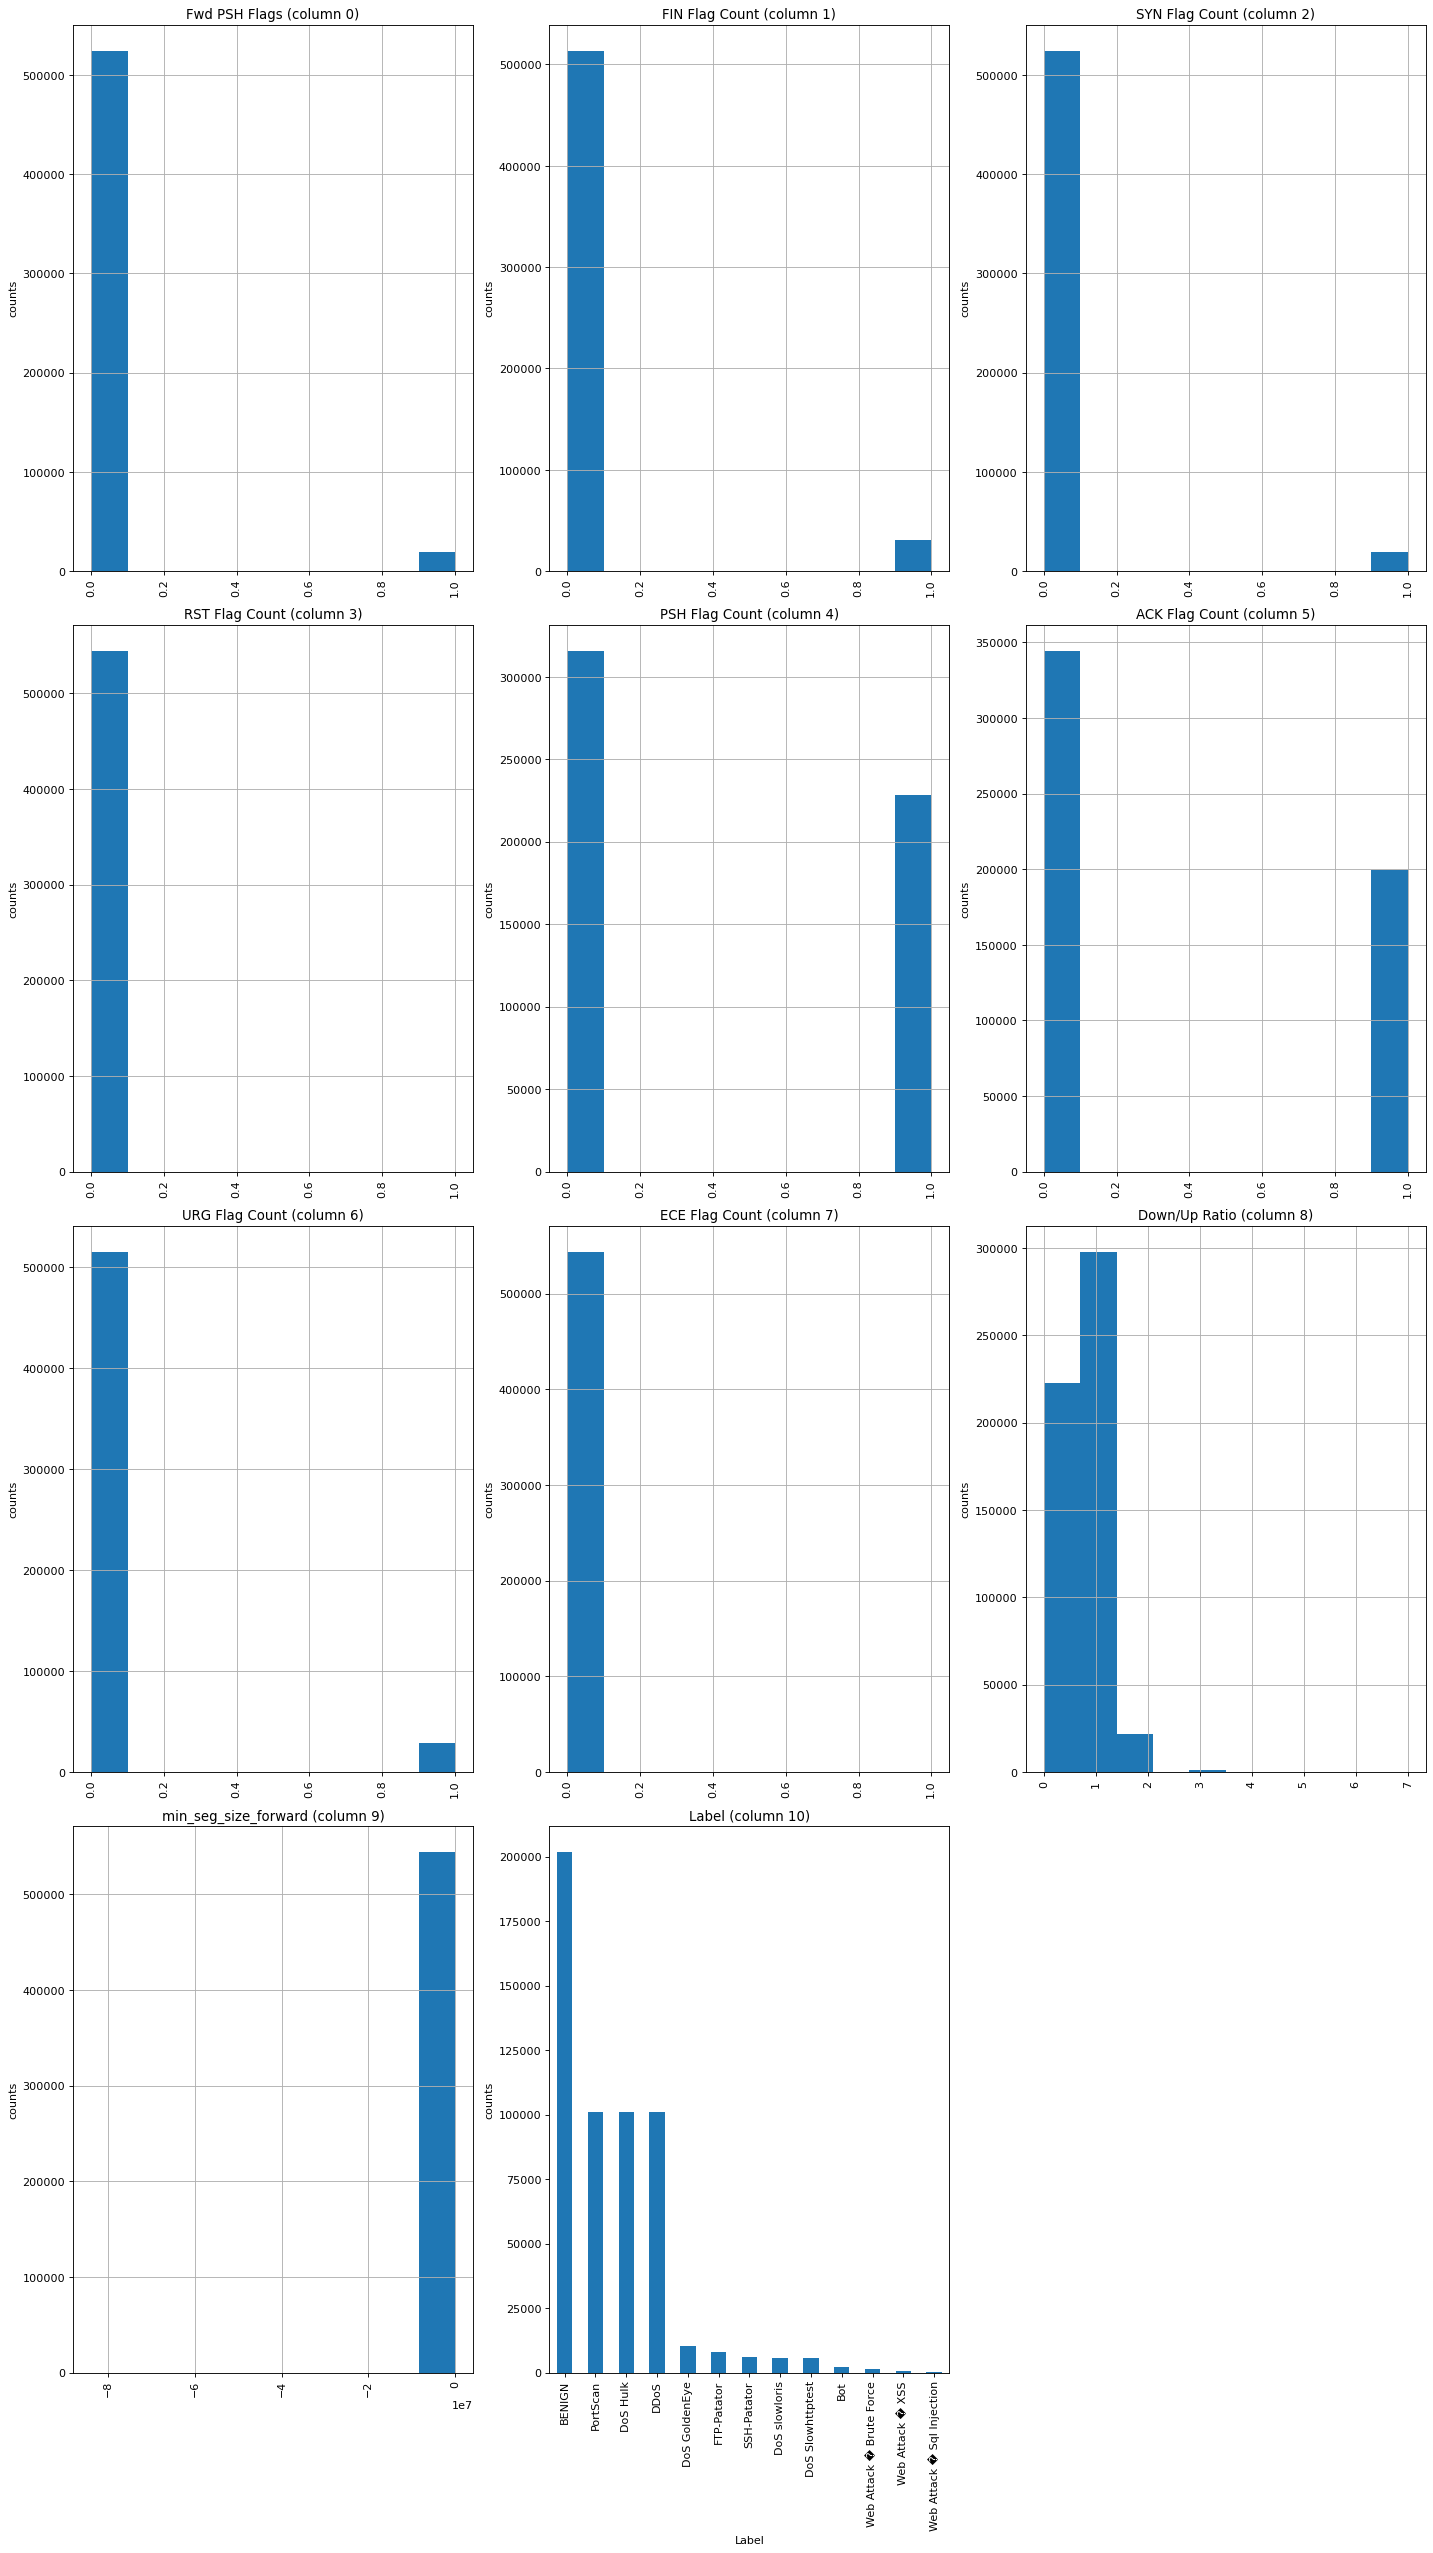

In [11]:
plt.rcParams['figure.figsize'] = (50, 50)

plot_per_column_distribution(df, 79, 3)

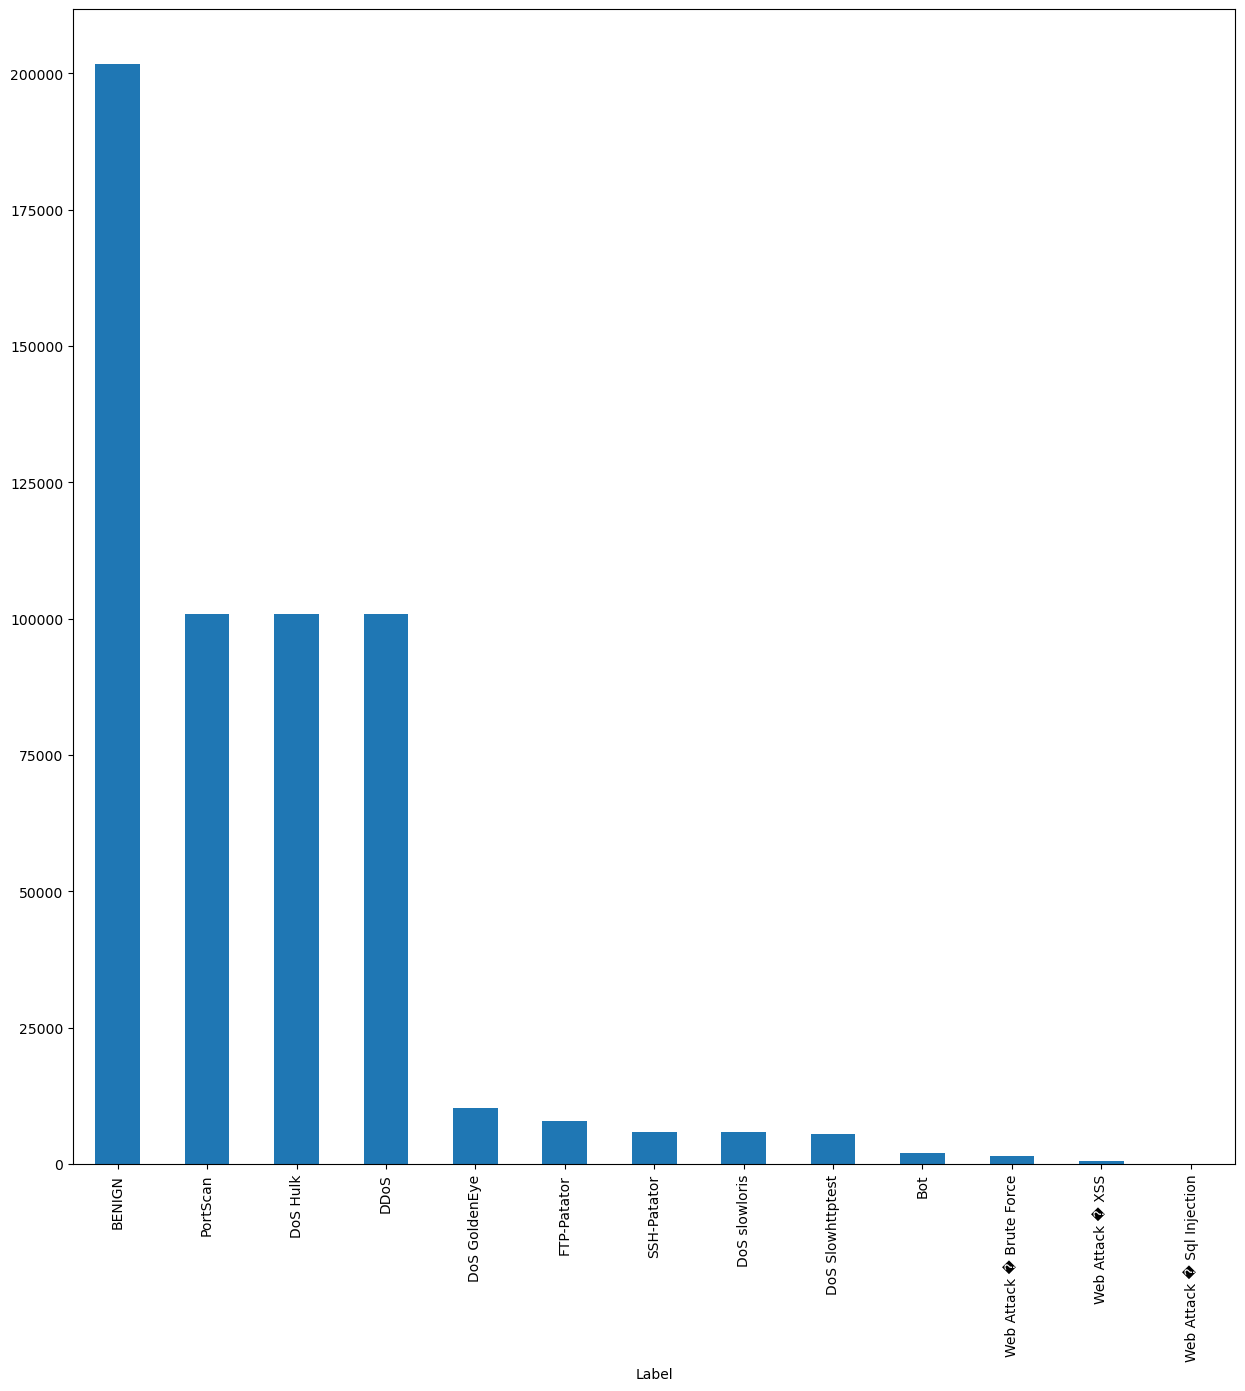

In [12]:
def bar_graph(feature):
    df[feature].value_counts().plot(kind="bar")

plt.rcParams['figure.figsize'] = (15,15)
bar_graph("Label")

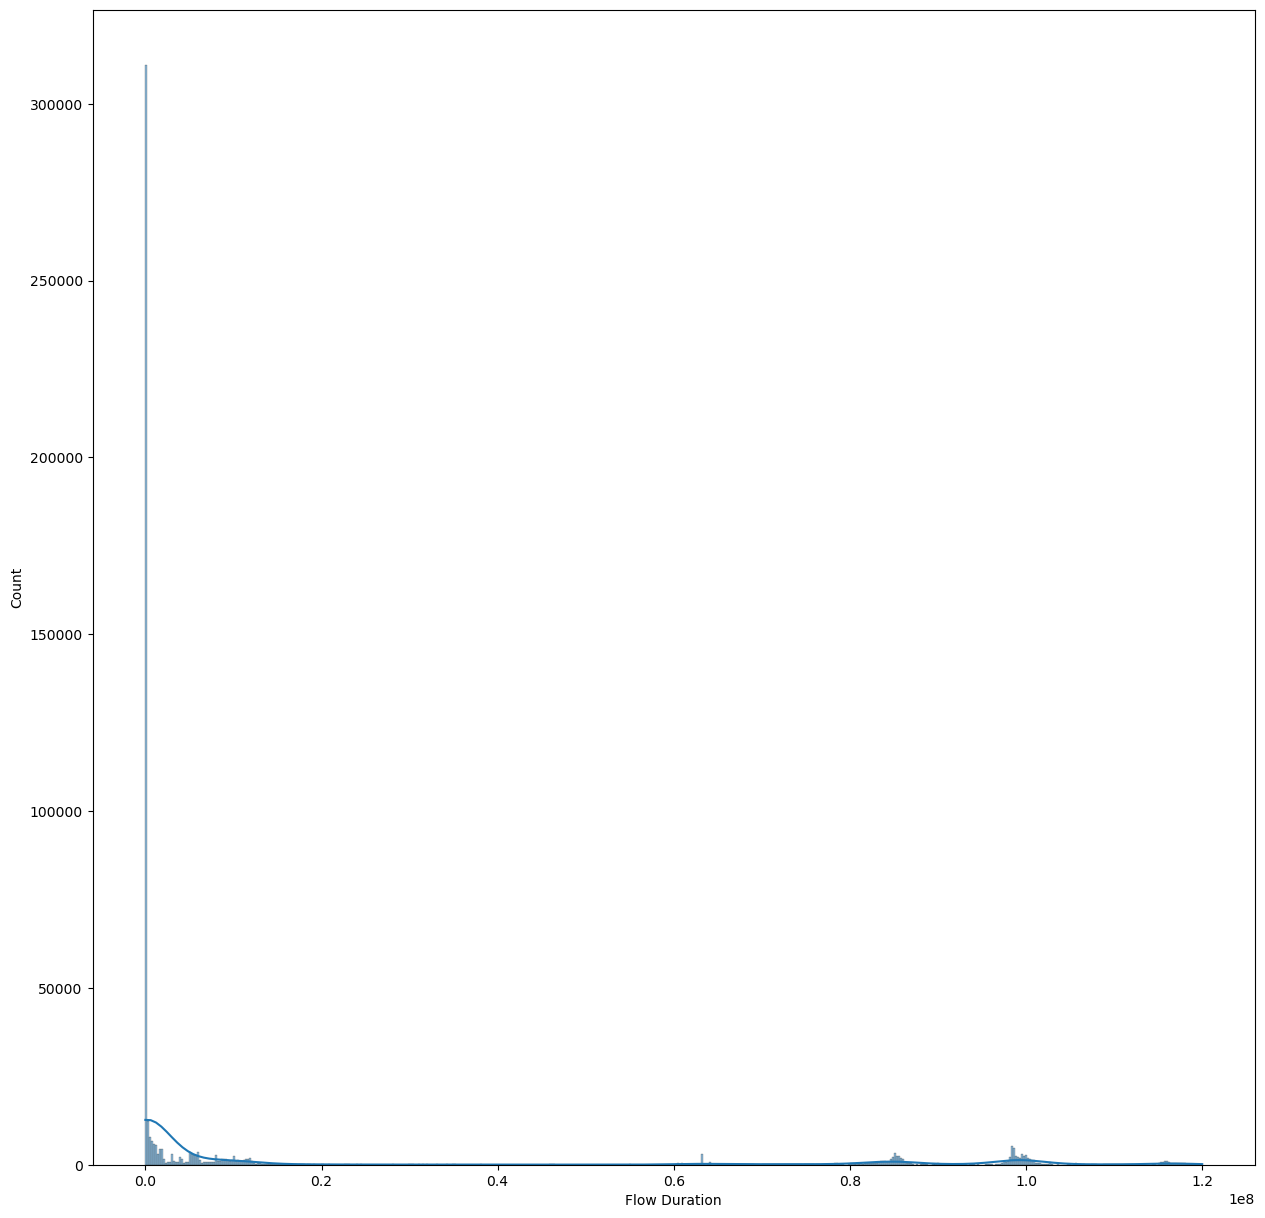

In [13]:
sns.histplot(df['Flow Duration'], kde=True)
plt.show()

In [14]:
df.columns = df.columns.str.strip()
# 제거 전 개수 확인
#Flow Duration은 네트워크 연결 지속시간을 의미하며, 음수 값은 물리적으로 불가능한 값이다. 따라서 해당 데이터를 이상값으로 판단하여 제거하였다.
neg_count = (df['Flow Duration'] < 0).sum()
print("음수 개수:", neg_count)

# 음수 제거
df = df[df['Flow Duration'] >= 0]

# 무한대 값(inf, -inf)을 NaN(결측치)로 변환
# → 0으로 나누는 계산 오류에서 발생한 값이며, 모델 학습에 사용할 수 없음
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 완전히 동일한 행(중복 데이터) 제거
# → 중복 데이터는 모델 학습 시 특정 패턴을 과도하게 반영하여 bias를 유발할 수 있음
df.drop_duplicates(inplace=True)

# 결측치(NaN)가 포함된 행 제거
# → 머신러닝 모델은 NaN 값을 처리하지 못하므로 제거하여 데이터 품질을 향상시킴
df.dropna(inplace=True)
# 제거 후 확인
print("제거 후 데이터 크기:", df.shape)

음수 개수: 9
제거 후 데이터 크기: (472354, 79)


In [16]:
df['Label'] = df['Label'].astype(str)

df['Label'] = df['Label'].str.replace('�', '-')  # 깨진 문자 수정
df['Label'] = df['Label'].str.replace('  ', ' ')  # 공백 정리
df['Label'] = df['Label'].str.strip()

print(df['Label'].value_counts())

Label
BENIGN                        194386
DDoS                          100824
DoS Hulk                       76080
PortScan                       66924
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack - Brute Force        1470
Web Attack - XSS                 652
Web Attack - Sql Injection        21
Name: count, dtype: int64


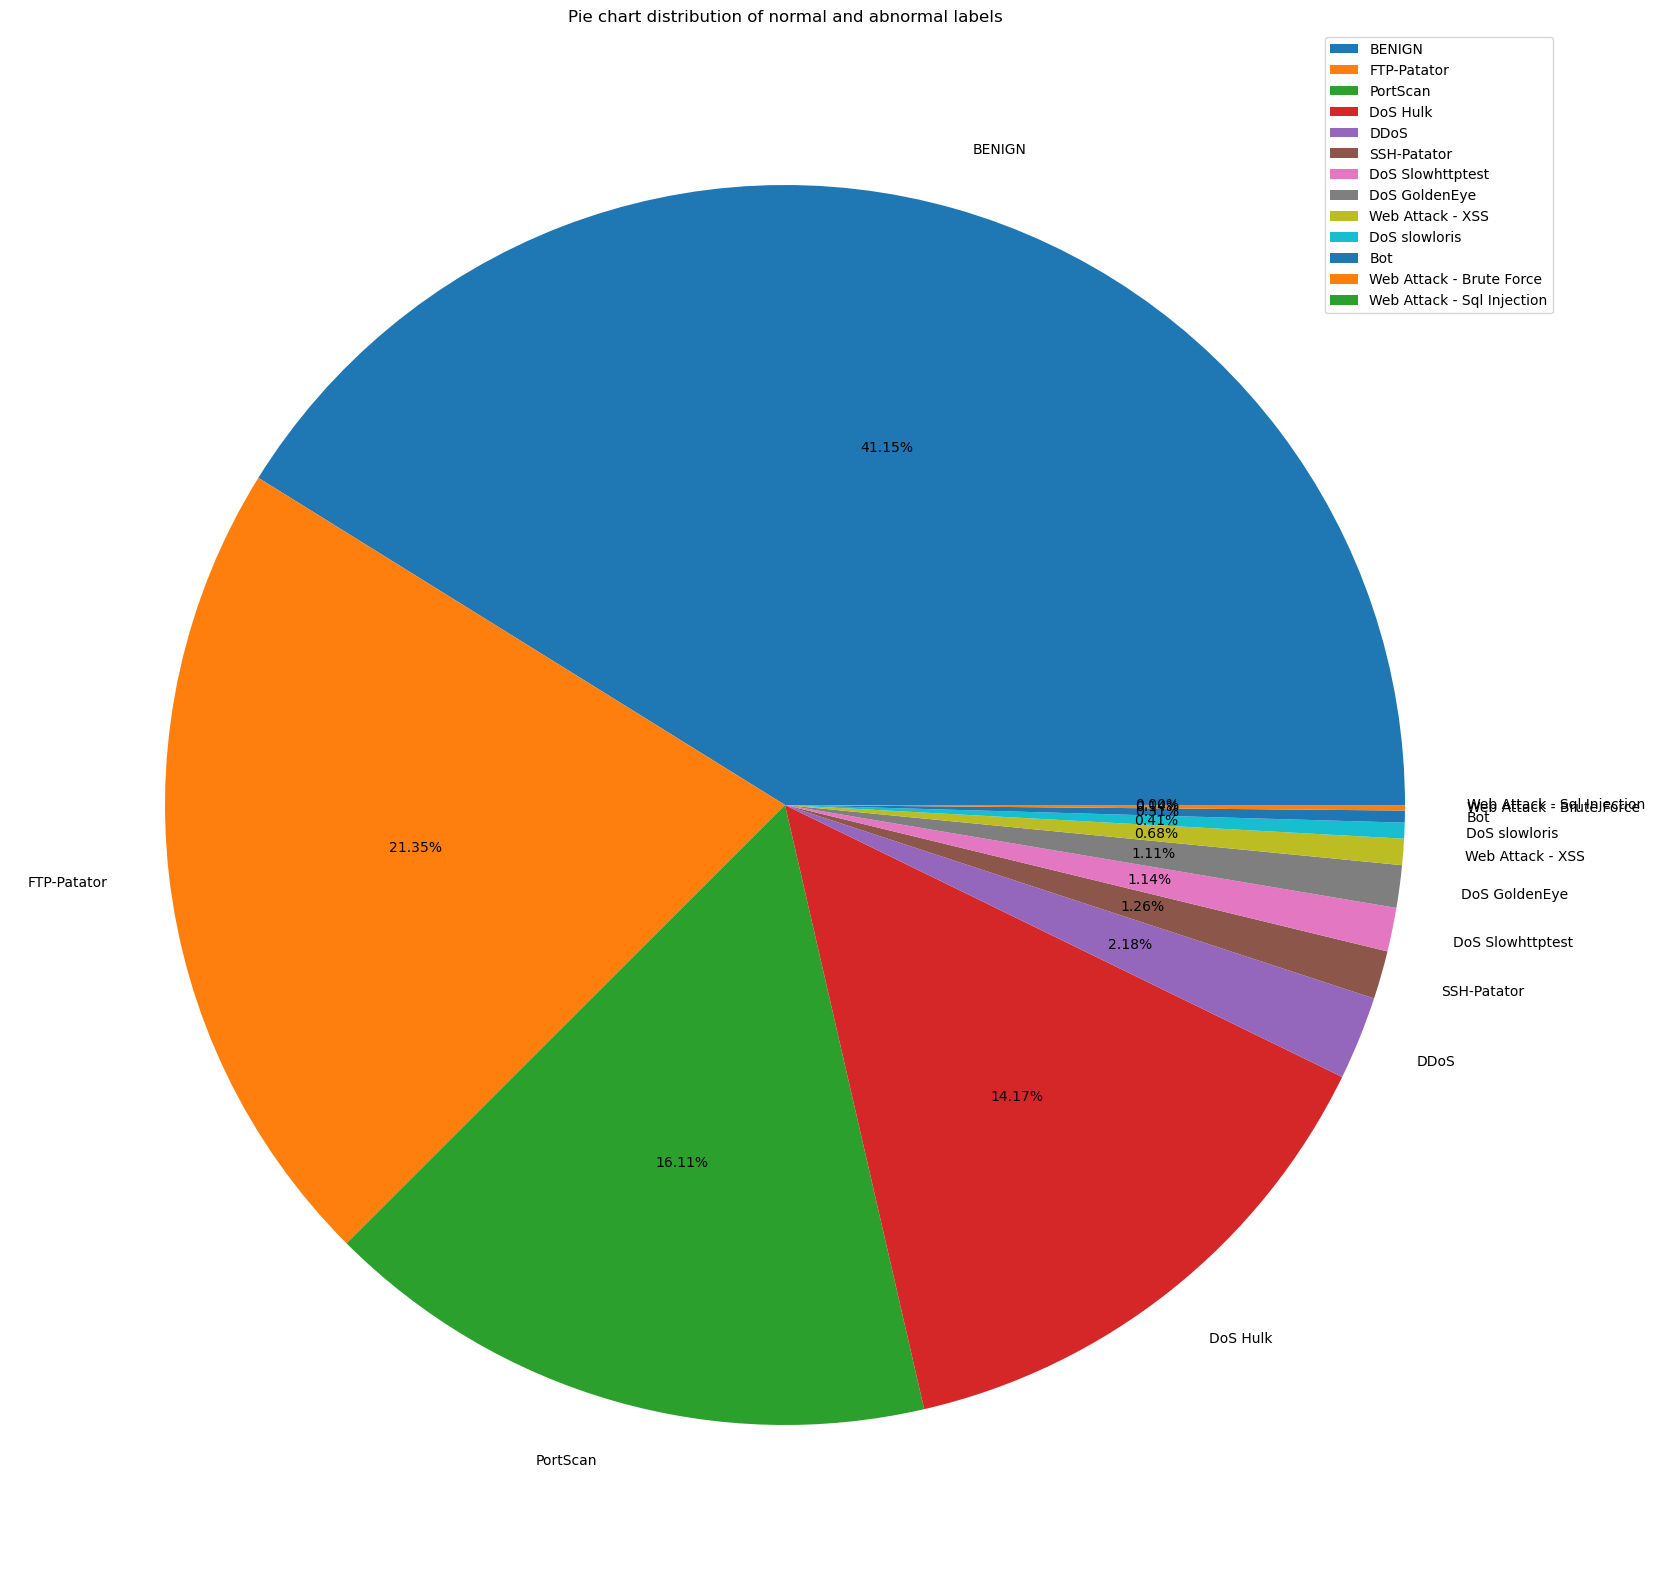

In [17]:
plt.figure(figsize=(20,30))
plt.pie(df['Label'].value_counts(),labels=df['Label'].unique(),autopct='%0.2f%%')
plt.title("Pie chart distribution of normal and abnormal labels")
plt.legend()
plt.show()

In [18]:
# 유지할 클래스 목록 (데이터 수가 적은 클래스 → 전부 사용)
classes_to_keep = [
    'DoS GoldenEye','FTP-Patator','SSH-Patator','DoS slowloris',
    'DoS Slowhttptest','Bot', 'Web Attack - Brute Force',
    'Web Attack - XSS', 'Infiltration','Web Attack - Sql Injection', 'Heartbleed'
]

# 데이터가 너무 많은 클래스 (일부만 사용하여 균형 맞춤)
classes_to_limit = ['BENIGN', 'DoS Hulk', 'PortScan', 'DDoS']


# 작은 클래스: 모든 데이터 유지
# → 데이터가 적기 때문에 손실 없이 그대로 사용
df_keep = df[df['Label'].isin(classes_to_keep)]


# 큰 클래스: 각 클래스별로 일정 개수만 선택 (50,000개)
# → 데이터가 많으면 모델이 해당 클래스에 치우치는 문제 발생
df_limit = df[df['Label'].isin(classes_to_limit)] \
            .groupby('Label') \
            .head(50000)


# 작은 클래스 + 큰 클래스 일부를 합침
# → 전체 데이터 균형 맞춤
result_df = pd.concat([df_keep, df_limit])


# 데이터 섞기 (shuffle)
# → 클래스 순서가 섞이도록 해서 모델 학습 안정성 확보
result_df = result_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [19]:
print(df['Label'].value_counts())

Label
BENIGN                        194386
DDoS                          100824
DoS Hulk                       76080
PortScan                       66924
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack - Brute Force        1470
Web Attack - XSS                 652
Web Attack - Sql Injection        21
Name: count, dtype: int64


In [20]:
df_limit_counts = df_limit['Label'].value_counts()
print(df_limit_counts)

Label
BENIGN      50000
PortScan    50000
DoS Hulk    50000
DDoS        50000
Name: count, dtype: int64


In [22]:
print(df_keep['Label'].value_counts())

Label
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
Bot                            1948
Web Attack - Brute Force       1470
Web Attack - XSS                652
Web Attack - Sql Injection       21
Name: count, dtype: int64


In [24]:
# 데이터 전처리 및 샘플링 이후,
# 각 클래스별 데이터 개수를 확인하기 위한 코드

for label in classes_to_limit:
    
    # 특정 클래스(label)에 해당하는 데이터만 추출
    # shape[0]을 통해 해당 클래스의 데이터 개수 계산
    count = df[df['Label'] == label].shape[0]
    
    # 클래스 이름과 데이터 개수를 출력하여
    # 샘플링이 정상적으로 수행되었는지 검증
    print(f"{label}: {count} After clean")

BENIGN: 194386 After clean
DoS Hulk: 76080 After clean
PortScan: 66924 After clean
DDoS: 100824 After clean


In [25]:
# result_df를 복사하여 원본 데이터 손상 방지
df_encoded = result_df.copy()

# LabelEncoder 객체 생성
# → 문자열 라벨을 숫자로 변환하기 위한 도구
le = LabelEncoder()

# 'Label' 컬럼을 숫자로 변환 (인코딩)
# 예: 'BENIGN' → 0, 'DDoS' → 1 ...
df_encoded['Label'] = le.fit_transform(result_df['Label'])

# 원래 라벨과 숫자 매핑 관계 생성
# → 어떤 라벨이 어떤 숫자로 바뀌었는지 확인하기 위함
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# 라벨 변환 결과 출력
print("Label Mapping:")
print(label_mapping)

# 인코딩된 데이터 일부 출력
print("\nEncoded DataFrame:")
df_encoded.head()

Label Mapping:
{'BENIGN': 0, 'Bot': 1, 'DDoS': 2, 'DoS GoldenEye': 3, 'DoS Hulk': 4, 'DoS Slowhttptest': 5, 'DoS slowloris': 6, 'FTP-Patator': 7, 'PortScan': 8, 'SSH-Patator': 9, 'Web Attack - Brute Force': 10, 'Web Attack - Sql Injection': 11, 'Web Attack - XSS': 12}

Encoded DataFrame:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,85634040,9,6,326,11595,326,0,36.222222,108.666667,...,32,8007.0,0.0,8007,8007,85500000.0,0.0,85500000,85500000,4
1,80,1530625,2,2,12,11,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,4
2,53,51114,2,2,92,170,46,46,46.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
3,80,6106239,4,0,24,0,6,6,6.000000,0.000000,...,20,1022.0,0.0,1022,1022,6105217.0,0.0,6105217,6105217,2
4,80,470,1,2,239,483,239,239,239.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,6


In [26]:
import joblib

# 라벨 인코딩 정보를 저장하기 위한 파일 경로 설정
encoder_file_path = 'label_encoder.pkl'

# LabelEncoder 객체를 파일로 저장
# → 학습 시 사용한 라벨 매핑 정보를 유지하여,
#    추후 모델 적용 및 시연 시 동일한 기준으로 라벨을 해석할 수 있도록 함
joblib.dump(le, encoder_file_path)

['label_encoder.pkl']

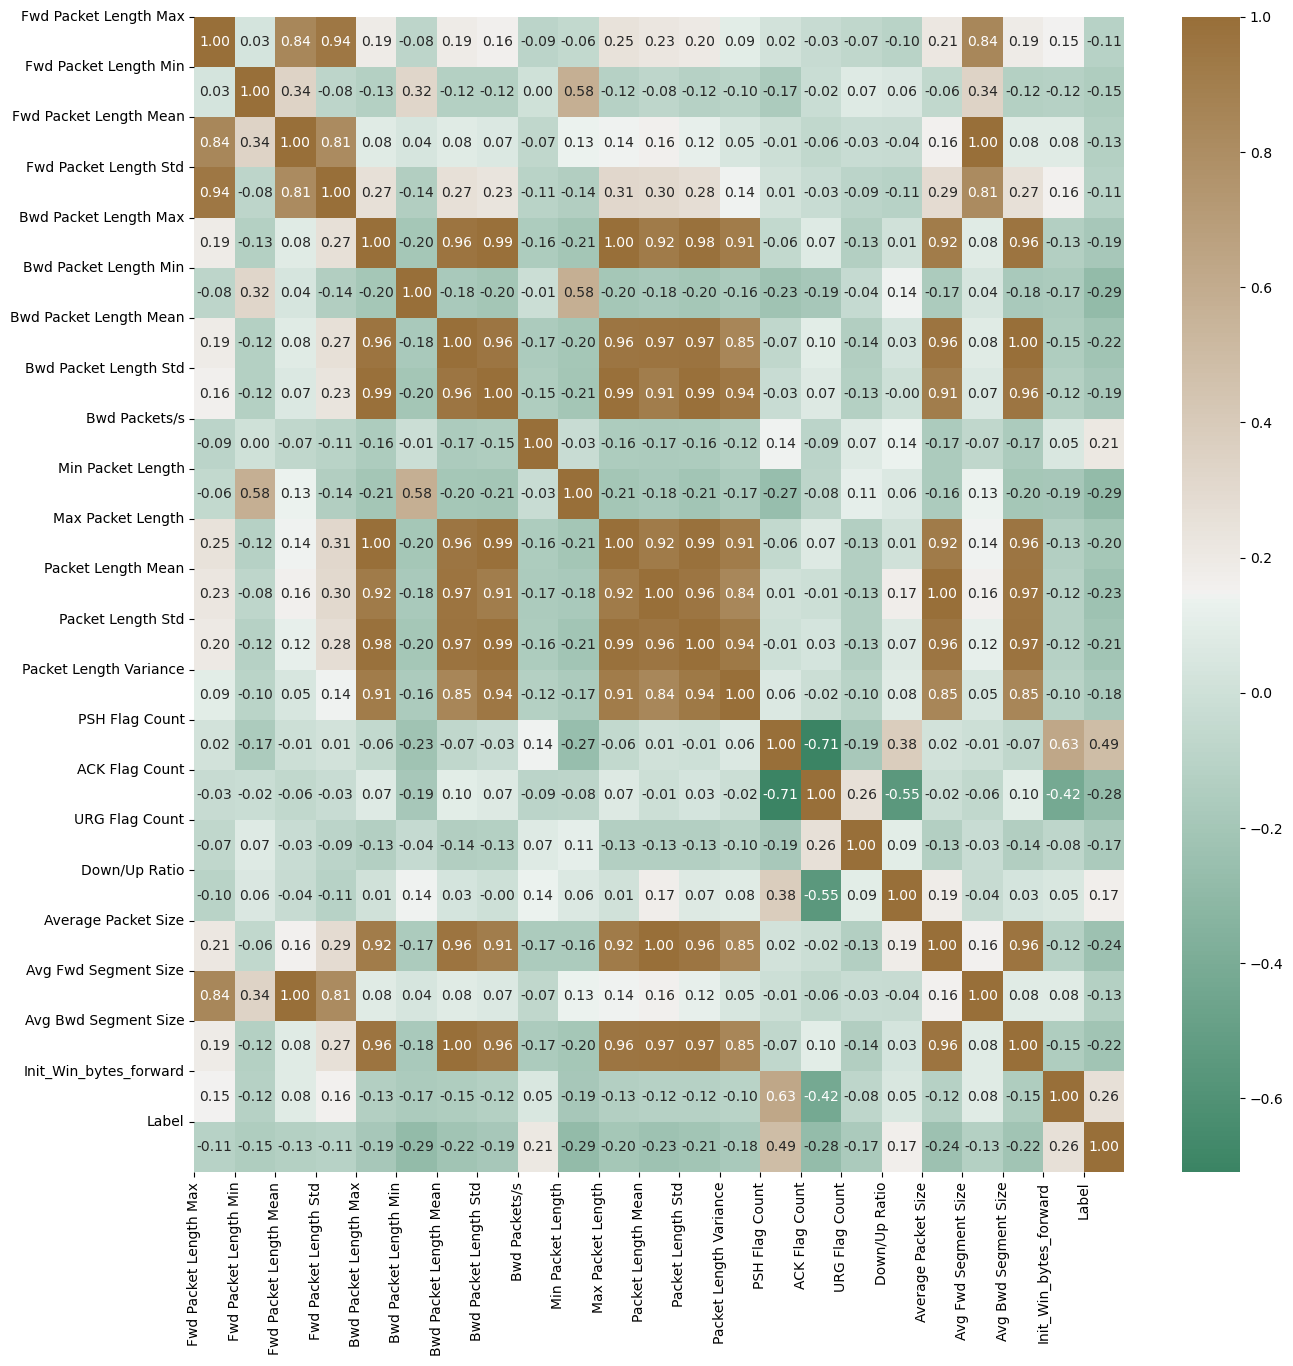

In [28]:
# 상관계수 기준값 설정 (Label과의 상관관계가 이 값 이상인 변수만 선택)
correlation_threshold = 0.1 

# 전체 데이터프레임의 상관계수 행렬 계산
corr = df_encoded.corr()

# Label 컬럼과의 상관계수 절댓값이 threshold 이상인 컬럼만 선택
columns_to_include = corr.columns[abs(corr['Label']) >= correlation_threshold]

# 선택된 컬럼들만으로 상관계수 행렬 필터링
filtered_corr = corr.loc[columns_to_include, columns_to_include]

# 그래프 크기 설정
fig, ax = plt.subplots(figsize=(15, 15))

# 색상 팔레트 설정 (양/음 상관관계 구분 잘 보이게)
colormap = sns.diverging_palette(150, 50, as_cmap=True)

# 히트맵 시각화
sns.heatmap(filtered_corr, 
            cmap=colormap,     # 컬러맵 적용
            annot=True,        # 값 표시
            fmt=".2f")         # 소수점 2자리

# x축, y축 라벨 설정
plt.xticks(range(len(filtered_corr.columns)), filtered_corr.columns)
plt.yticks(range(len(filtered_corr.columns)), filtered_corr.columns)

# 그래프 출력
plt.show()

In [33]:
# Label 컬럼과 다른 변수들 간의 상관계수만 가져오기
# corr['Label'] → Label과 모든 변수의 상관계수
# drop('Label') → 자기 자신(Label vs Label = 1)은 제거
corr_with_label = corr['Label'].drop('Label')


# 보기 좋게 DataFrame 형태로 정리
corr_df = pd.DataFrame({
    'Feature': corr_with_label.index,          # 변수 이름 (컬럼명)
    'Correlation': corr_with_label.values,     # Label과의 상관계수 (양/음 포함)
    'Abs_Correlation': corr_with_label.abs().values  # 절댓값 (중요도 기준)
})


# 절댓값 기준으로 정렬 (영향력이 큰 변수부터 보기 위해)
# ascending=False → 큰 값부터 내림차순
corr_df = corr_df.sort_values(by='Abs_Correlation', ascending=False)


# 상위 20개 변수 출력 (Label에 가장 영향 큰 특성들)
print(corr_df.head(20))

                   Feature  Correlation  Abs_Correlation
46          PSH Flag Count     0.488491         0.488491
38       Min Packet Length    -0.286478         0.286478
11   Bwd Packet Length Min    -0.285411         0.285411
47          ACK Flag Count    -0.276844         0.276844
66  Init_Win_bytes_forward     0.264916         0.264916
52     Average Packet Size    -0.237220         0.237220
40      Packet Length Mean    -0.233564         0.233564
54    Avg Bwd Segment Size    -0.216548         0.216548
12  Bwd Packet Length Mean    -0.216548         0.216548
41       Packet Length Std    -0.210228         0.210228
37           Bwd Packets/s     0.209551         0.209551
39       Max Packet Length    -0.196885         0.196885
13   Bwd Packet Length Std    -0.193742         0.193742
10   Bwd Packet Length Max    -0.193261         0.193261
42  Packet Length Variance    -0.181123         0.181123
48          URG Flag Count    -0.171606         0.171606
51           Down/Up Ratio     

In [36]:
X = df_encoded.drop('Label', axis=1)
y = df_encoded['Label']

In [37]:

# 데이터를 학습용(train) / 테스트용(test)으로 분리 (80:20)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest 모델 생성
# n_estimators=100 → 의사결정나무 100개 사용
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
)

# 모델 학습 (train 데이터로 패턴 학습)
rf_classifier.fit(x_train, y_train)

# 각 feature(변수)의 중요도 추출
feature_importances = rf_classifier.feature_importances_

# feature 이름 + 중요도를 DataFrame으로 정리
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# 중요도 기준으로 내림차순 정렬 (중요한 변수부터 위로)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', 
    ascending=False
)

# Random Forest의 feature importance를 기반으로 상위 20개 변수를 선택
top_features = feature_importance_df.head(20)['Feature'].tolist()

# 원본 데이터에서 선택된 feature + Label만 남기기
df_top_features = df_encoded[top_features + ['Label']]

# 결과 확인 (상위 feature만 포함된 데이터)
df_top_features.head()

,Fwd Packet Length Mean,Avg Fwd Segment Size,Flow IAT Max,Fwd Packet Length Max,Subflow Fwd Bytes,Flow Duration,Bwd Packets/s,Average Packet Size,Init_Win_bytes_backward,Fwd IAT Max,...,Total Length of Fwd Packets,Subflow Fwd Packets,Total Length of Bwd Packets,Destination Port,Bwd Header Length,Flow Packets/s,Init_Win_bytes_forward,Avg Bwd Segment Size,Fwd IAT Mean,Label
0,36.222222,36.222222,85500000,326,326,85634040,0.070066,794.733333,235,85500000,...,326,9,11595,80,200,0.175164,251,1932.5,10700000.0,4
1,6.000000,6.000000,1530025,6,12,1530625,1.306656,7.250000,235,600,...,12,2,11,80,64,2.613312,0,5.5,600.0,4
2,46.000000,46.000000,51107,46,92,51114,39.128223,77.000000,-1,4,...,92,2,170,53,40,78.256446,-1,85.0,4.0,0
3,6.000000,6.000000,6105217,6,24,6106239,0.000000,7.500000,-1,6105217,...,24,4,0,80,0,0.655068,256,0.0,2035413.0,2
4,239.000000,239.000000,466,239,239,470,4255.319149,320.333333,235,0,...,239,1,483,80,64,6382.978723,229,241.5,0.0,6


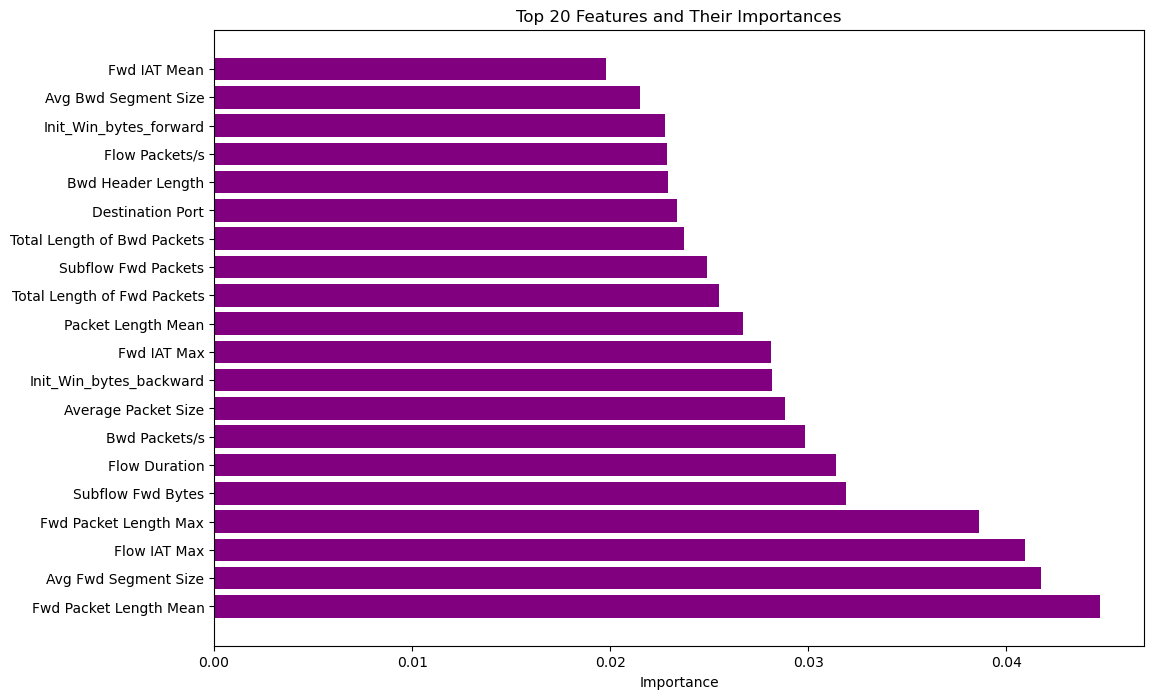

In [38]:
# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# 수평 막대그래프 생성 (Feature Importance 시각화)
plt.barh(
    top_features,                                 # y축: 상위 20개 feature 이름
    feature_importance_df.head(20)['Importance'], # x축: 각 feature의 중요도 값
    color='purple'                                # 막대 색상 설정
)

# x축 라벨 설정 (중요도 값 의미)
plt.xlabel('Importance')

# 그래프 제목 설정
plt.title('Top 20 Features and Their Importances')

# 그래프 출력
plt.show()

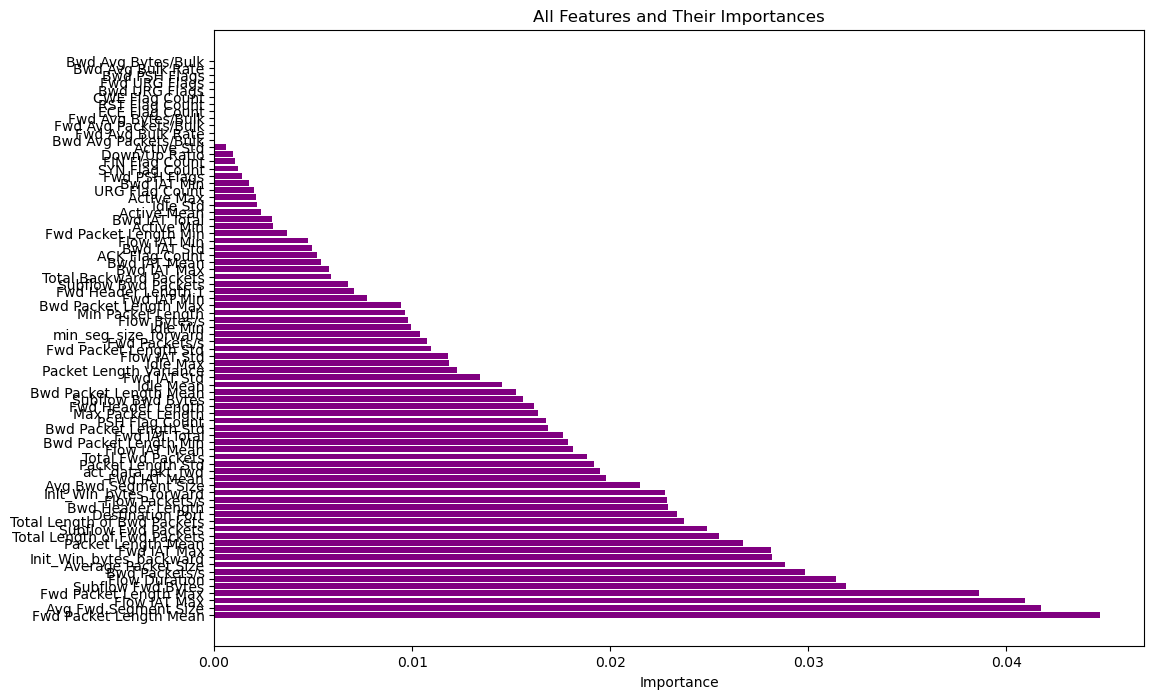

In [39]:
# Feature Importance 기준으로 내림차순 정렬 (중요한 변수 먼저)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', 
    ascending=False
)

# 그래프 크기 설정
plt.figure(figsize=(12, 8))

# 모든 feature에 대한 중요도를 수평 막대그래프로 시각화
plt.barh(
    feature_importance_df['Feature'],     # y축: 모든 feature 이름
    feature_importance_df['Importance'],  # x축: 중요도 값
    color='purple'                        # 막대 색상
)

# x축 라벨 설정
plt.xlabel('Importance')

# 그래프 제목 설정
plt.title('All Features and Their Importances')

# 그래프 출력
plt.show()

In [40]:
df_top_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234140 entries, 0 to 234139
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Fwd Packet Length Mean       234140 non-null  float64
 1   Avg Fwd Segment Size         234140 non-null  float64
 2   Flow IAT Max                 234140 non-null  int64  
 3   Fwd Packet Length Max        234140 non-null  int64  
 4   Subflow Fwd Bytes            234140 non-null  int64  
 5   Flow Duration                234140 non-null  int64  
 6   Bwd Packets/s                234140 non-null  float64
 7   Average Packet Size          234140 non-null  float64
 8   Init_Win_bytes_backward      234140 non-null  int64  
 9   Fwd IAT Max                  234140 non-null  int64  
 10  Packet Length Mean           234140 non-null  float64
 11  Total Length of Fwd Packets  234140 non-null  int64  
 12  Subflow Fwd Packets          234140 non-null  int64  
 13 

In [41]:
# =========================
# 전체 feature / Top feature 데이터셋 분리
# =========================

# 1) 전체 feature 데이터셋
X_all_features = df_encoded.drop('Label', axis=1)
y_all_features = df_encoded['Label']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_features, y_all_features, test_size=0.2, random_state=42
)

# 2) Top feature 데이터셋
X_top_features = df_top_features.drop('Label', axis=1)
y_top_features = df_top_features['Label']

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top_features, y_top_features, test_size=0.2, random_state=42
)

print("전체 feature 개수:", X_all_features.shape[1])
print("Top feature 개수:", X_top_features.shape[1])
print("전체 feature train shape:", X_train_all.shape)
print("Top feature train shape:", X_train_top.shape)

전체 feature 개수: 78
Top feature 개수: 20
전체 feature train shape: (187312, 78)
Top feature train shape: (187312, 20)


In [42]:
X_train.info()

NameError: name 'X_train' is not defined

In [ ]:
X_top_features.to_csv('X_top_features.csv', index=False)
y_top_features.to_csv('y_top_features.csv', index=False)

In [ ]:
print("Infinity values in X_train:", np.any(np.isinf(X_train)))
print("NaN values in X_train:", np.any(np.isnan(X_train)))

In [ ]:
# 경고 메시지 제거 (불필요한 warning 출력 안 보이게)
import warnings
warnings.filterwarnings('ignore')

# sklearn의 평가 지표 모듈 import
from sklearn import metrics

# 데이터셋을 직접 받아서 성능 출력하는 함수
def print_all_accuracy_matric_dataset(algorithm, name, X_train, X_test, y_train, y_test):

    # 학습 데이터 예측
    y_train_pred = algorithm.predict(X_train)

    # 테스트 데이터 예측
    y_test_pred = algorithm.predict(X_test)

    # Accuracy
    acc_train = metrics.accuracy_score(y_train, y_train_pred)
    acc_test = metrics.accuracy_score(y_test, y_test_pred)

    print(name, " : Accuracy on training Data: {:.3f}".format(acc_train))
    print(name, " : Accuracy on test Data: {:.3f}".format(acc_test))
    print()

    # F1-score
    f1_train = metrics.f1_score(y_train, y_train_pred, average='macro')
    f1_test = metrics.f1_score(y_test, y_test_pred, average='macro')

    print(name, " : f1_score on training Data: {:.3f}".format(f1_train))
    print(name, " : f1_score on test Data: {:.3f}".format(f1_test))
    print()

    # Recall
    recall_train = metrics.recall_score(y_train, y_train_pred, average='macro')
    recall_test = metrics.recall_score(y_test, y_test_pred, average='macro')

    print(name, " : Recall on training Data: {:.3f}".format(recall_train))
    print(name, " : Recall on test Data: {:.3f}".format(recall_test))
    print()

    # Precision
    precision_train = metrics.precision_score(y_train, y_train_pred, average='macro')
    precision_test = metrics.precision_score(y_test, y_test_pred, average='macro')

    print(name, " : Precision on training Data: {:.3f}".format(precision_train))
    print(name, " : Precision on test Data: {:.3f}".format(precision_test))

    # Classification Report
    print('\n\nClassification Report\n\n')
    print(metrics.classification_report(y_test, y_test_pred))
    print('\n\n')

In [ ]:
def evaluate_model_for_comparison(model, X_train, X_test, y_train, y_test, model_name, dataset_name):
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # 결과 저장
    result = {
        'Dataset': dataset_name,
        'Model': model_name,
        'Train_Accuracy': metrics.accuracy_score(y_train, y_pred_train),
        'Test_Accuracy': metrics.accuracy_score(y_test, y_pred_test),
        'Train_F1_Macro': metrics.f1_score(y_train, y_pred_train, average='macro'),
        'Test_F1_Macro': metrics.f1_score(y_test, y_pred_test, average='macro'),
        'Train_Recall_Macro': metrics.recall_score(y_train, y_pred_train, average='macro'),
        'Test_Recall_Macro': metrics.recall_score(y_test, y_pred_test, average='macro'),
        'Train_Precision_Macro': metrics.precision_score(y_train, y_pred_train, average='macro'),
        'Test_Precision_Macro': metrics.precision_score(y_test, y_pred_test, average='macro')
    }
    
    return result

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

comparison_models = {
    'DecisionTree': DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'CatBoost': CatBoostClassifier(iterations=10, learning_rate=0.1, depth=6, verbose=0)
}

In [379]:
comparison_results = []

for model_name, model in comparison_models.items():
    # 전체 feature
    comparison_results.append(
        evaluate_model_for_comparison(
            model,
            X_train_all, X_test_all,
            y_train_all, y_test_all,
            model_name,
            'All Features'
        )
    )
    
    # Top feature
    comparison_results.append(
        evaluate_model_for_comparison(
            model,
            X_train_top, X_test_top,
            y_train_top, y_test_top,
            model_name,
            'Top Features'
        )
    )

comparison_results_df = pd.DataFrame(comparison_results)
comparison_results_df = comparison_results_df.sort_values(by=['Model', 'Dataset']).reset_index(drop=True)

comparison_results_df

KeyboardInterrupt: 

In [372]:
comparison_summary = pd.DataFrame({
    'All_Test_Accuracy': comparison_results_df[comparison_results_df['Dataset'] == 'All Features'].set_index('Model')['Test_Accuracy'],
    'Top_Test_Accuracy': comparison_results_df[comparison_results_df['Dataset'] == 'Top Features'].set_index('Model')['Test_Accuracy'],
    'All_Test_F1': comparison_results_df[comparison_results_df['Dataset'] == 'All Features'].set_index('Model')['Test_F1_Macro'],
    'Top_Test_F1': comparison_results_df[comparison_results_df['Dataset'] == 'Top Features'].set_index('Model')['Test_F1_Macro'],
    'All_Test_Recall': comparison_results_df[comparison_results_df['Dataset'] == 'All Features'].set_index('Model')['Test_Recall_Macro'],
    'Top_Test_Recall': comparison_results_df[comparison_results_df['Dataset'] == 'Top Features'].set_index('Model')['Test_Recall_Macro'],
    'All_Test_Precision': comparison_results_df[comparison_results_df['Dataset'] == 'All Features'].set_index('Model')['Test_Precision_Macro'],
    'Top_Test_Precision': comparison_results_df[comparison_results_df['Dataset'] == 'Top Features'].set_index('Model')['Test_Precision_Macro'],
})

comparison_summary['Accuracy_Diff(Top-All)'] = comparison_summary['Top_Test_Accuracy'] - comparison_summary['All_Test_Accuracy']
comparison_summary['F1_Diff(Top-All)'] = comparison_summary['Top_Test_F1'] - comparison_summary['All_Test_F1']

comparison_summary = comparison_summary.sort_values(by='Accuracy_Diff(Top-All)', ascending=False)
comparison_summary

,All_Test_Accuracy,Top_Test_Accuracy,All_Test_F1,Top_Test_F1,All_Test_Recall,Top_Test_Recall,All_Test_Precision,Top_Test_Precision,Accuracy_Diff(Top-All),F1_Diff(Top-All)
Model,,,,,,,,,,
NaiveBayes,0.456799,0.583027,0.398477,0.407859,0.595829,0.510116,0.453438,0.468624,0.126228,0.009382
RandomForest,0.995750,0.995558,0.927471,0.922592,0.918907,0.916003,0.938165,0.930904,-0.000192,-0.004878
CatBoost,0.969014,0.965491,0.744013,0.712036,0.744125,0.722433,0.778501,0.706391,-0.003524,-0.031977
KNN,0.986333,0.973947,0.860358,0.848911,0.851038,0.839069,0.911063,0.899924,-0.012386,-0.011446
DecisionTree,0.887802,0.858995,0.540043,0.486292,0.544763,0.488243,0.544337,0.490483,-0.028808,-0.053751
LogisticRegression,0.867793,0.553771,0.679440,0.208978,0.678813,0.216416,0.699597,0.214616,-0.314022,-0.470461


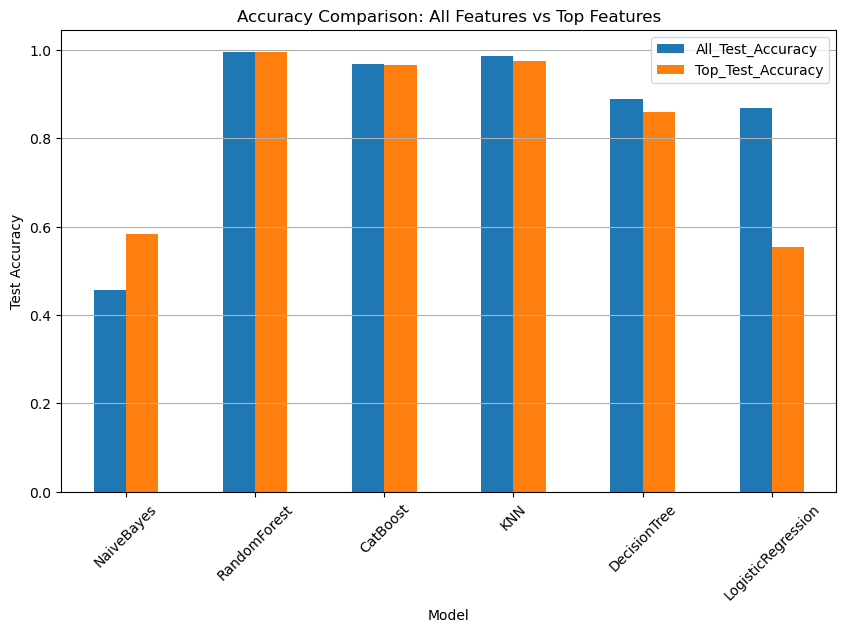

In [375]:
#정확도 비교

comparison_summary[['All_Test_Accuracy', 'Top_Test_Accuracy']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Accuracy Comparison: All Features vs Top Features')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

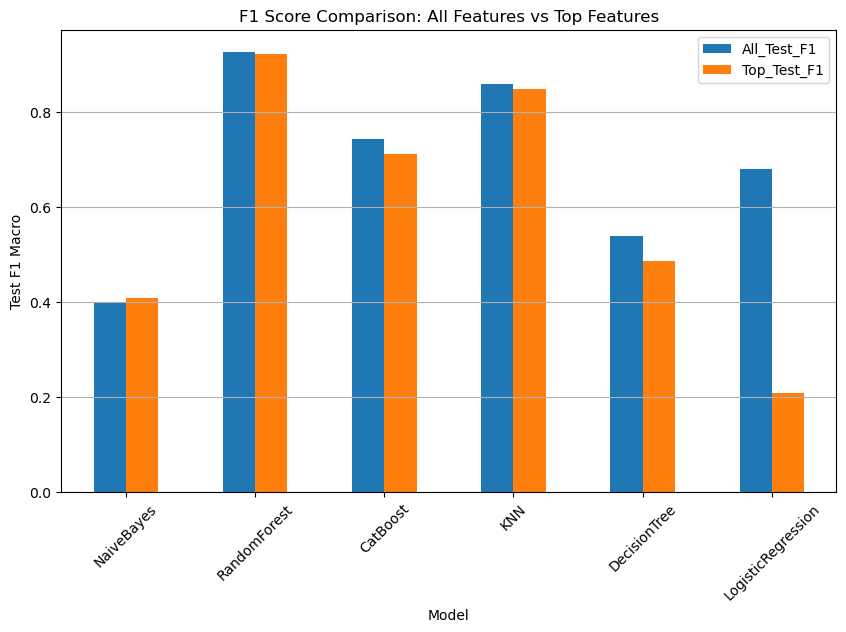

In [377]:
#F1비교
comparison_summary[['All_Test_F1', 'Top_Test_F1']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('F1 Score Comparison: All Features vs Top Features')
plt.ylabel('Test F1 Macro')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [383]:
# Decision Tree 모델 import
from sklearn.tree import DecisionTreeClassifier

print("=" * 80)
print("DecisionTreeClassifier 비교: All Features vs Top Features")
print("=" * 80)

# ---------------------------
# 1) All Features
# ---------------------------
print("\n[All Features]\n")

clfd_all = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

clfd_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    clfd_all,
    'DecisionTreeClassifier (All Features)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(clfd_all, 'DecisionTreeClassifier_AllFeatures.joblib')


# ---------------------------
# 2) Top Features
# ---------------------------
print("\n[Top Features]\n")

clfd_top = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

clfd_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    clfd_top,
    'DecisionTreeClassifier (Top Features)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(clfd_top, 'DecisionTreeClassifier_TopFeatures.joblib')

DecisionTreeClassifier 비교: All Features vs Top Features

[All Features]

DecisionTreeClassifier (All Features)  : Accuracy on training Data: 0.887
DecisionTreeClassifier (All Features)  : Accuracy on test Data: 0.888

DecisionTreeClassifier (All Features)  : f1_score on training Data: 0.537
DecisionTreeClassifier (All Features)  : f1_score on test Data: 0.540

DecisionTreeClassifier (All Features)  : Recall on training Data: 0.543
DecisionTreeClassifier (All Features)  : Recall on test Data: 0.545

DecisionTreeClassifier (All Features)  : Precision on training Data: 0.539
DecisionTreeClassifier (All Features)  : Precision on test Data: 0.544


Classification Report


              precision    recall  f1-score   support

           0       0.75      0.97      0.84     10129
           1       0.92      0.60      0.73       407
           2       0.96      1.00      0.98      9954
           3       0.57      0.69      0.63      2099
           4       0.95      0.85      0.90      9857

['DecisionTreeClassifier_TopFeatures.joblib']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("RandomForestClassifier 비교: All Features vs Top Features")
print("=" * 80)

# All Features
print("\n[All Features]\n")

rf_all = RandomForestClassifier(random_state=42)
rf_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    rf_all, 'RandomForest (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(rf_all, 'RandomForest_All.joblib')

# Top Features
print("\n[Top Features]\n")

rf_top = RandomForestClassifier(random_state=42)
rf_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    rf_top, 'RandomForest (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(rf_top, 'RandomForest_Top.joblib')

In [387]:
from sklearn.neighbors import KNeighborsClassifier

print("=" * 80)
print("KNN 비교: All Features vs Top Features")
print("=" * 80)

# All
print("\n[All Features]\n")

knn_all = KNeighborsClassifier(n_neighbors=3)
knn_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    knn_all, 'KNN (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(knn_all, 'KNN_All.joblib')

# Top
print("\n[Top Features]\n")

knn_top = KNeighborsClassifier(n_neighbors=3)
knn_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    knn_top, 'KNN (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(knn_top, 'KNN_Top.joblib')

KNN 비교: All Features vs Top Features

[All Features]

KNN (All)  : Accuracy on training Data: 0.992
KNN (All)  : Accuracy on test Data: 0.986

KNN (All)  : f1_score on training Data: 0.910
KNN (All)  : f1_score on test Data: 0.860

KNN (All)  : Recall on training Data: 0.896
KNN (All)  : Recall on test Data: 0.851

KNN (All)  : Precision on training Data: 0.945
KNN (All)  : Precision on test Data: 0.911


Classification Report


              precision    recall  f1-score   support

           0       0.99      0.98      0.98     10129
           1       0.83      0.90      0.86       407
           2       0.99      0.99      0.99      9954
           3       0.99      0.99      0.99      2099
           4       0.99      0.99      0.99      9857
           5       0.97      0.99      0.98      1051
           6       0.98      0.95      0.96      1014
           7       0.99      0.99      0.99      1189
           8       1.00      1.00      1.00     10033
           9       0.96   

['KNN_Top.joblib']

In [389]:
from sklearn.naive_bayes import GaussianNB

print("=" * 80)
print("NaiveBayes 비교: All Features vs Top Features")
print("=" * 80)

# All
print("\n[All Features]\n")

nb_all = GaussianNB()
nb_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    nb_all, 'NaiveBayes (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(nb_all, 'NaiveBayes_All.joblib')

# Top
print("\n[Top Features]\n")

nb_top = GaussianNB()
nb_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    nb_top, 'NaiveBayes (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(nb_top, 'NaiveBayes_Top.joblib')

NaiveBayes 비교: All Features vs Top Features

[All Features]

NaiveBayes (All)  : Accuracy on training Data: 0.458
NaiveBayes (All)  : Accuracy on test Data: 0.457

NaiveBayes (All)  : f1_score on training Data: 0.397
NaiveBayes (All)  : f1_score on test Data: 0.398

NaiveBayes (All)  : Recall on training Data: 0.601
NaiveBayes (All)  : Recall on test Data: 0.596

NaiveBayes (All)  : Precision on training Data: 0.451
NaiveBayes (All)  : Precision on test Data: 0.453


Classification Report


              precision    recall  f1-score   support

           0       0.99      0.06      0.11     10129
           1       0.05      0.58      0.10       407
           2       0.87      0.76      0.81      9954
           3       0.66      0.79      0.72      2099
           4       0.89      0.80      0.84      9857
           5       0.72      0.59      0.65      1051
           6       0.40      0.54      0.46      1014
           7       0.09      1.00      0.16      1189
           8     

['NaiveBayes_Top.joblib']

In [391]:
from xgboost import XGBClassifier

print("=" * 80)
print("XGBoost 비교: All Features vs Top Features")
print("=" * 80)

# All
print("\n[All Features]\n")

xgb_all = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    xgb_all, 'XGBoost (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(xgb_all, 'XGBoost_All.joblib')

# Top
print("\n[Top Features]\n")

xgb_top = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    xgb_top, 'XGBoost (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(xgb_top, 'XGBoost_Top.joblib')

XGBoost 비교: All Features vs Top Features

[All Features]

XGBoost (All)  : Accuracy on training Data: 0.997
XGBoost (All)  : Accuracy on test Data: 0.997

XGBoost (All)  : f1_score on training Data: 0.939
XGBoost (All)  : f1_score on test Data: 0.909

XGBoost (All)  : Recall on training Data: 0.936
XGBoost (All)  : Recall on test Data: 0.899

XGBoost (All)  : Precision on training Data: 0.967
XGBoost (All)  : Precision on test Data: 0.943


Classification Report


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10129
           1       1.00      1.00      1.00       407
           2       1.00      1.00      1.00      9954
           3       1.00      1.00      1.00      2099
           4       1.00      1.00      1.00      9857
           5       1.00      0.99      0.99      1051
           6       0.99      1.00      1.00      1014
           7       1.00      1.00      1.00      1189
           8       1.00      1.00      1.00 

['XGBoost_Top.joblib']

In [392]:
from catboost import CatBoostClassifier

print("=" * 80)
print("CatBoost 비교: All Features vs Top Features")
print("=" * 80)

# All
print("\n[All Features]\n")

cat_all = CatBoostClassifier(
    iterations=10,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    cat_all, 'CatBoost (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(cat_all, 'CatBoost_All.joblib')

# Top
print("\n[Top Features]\n")

cat_top = CatBoostClassifier(
    iterations=10,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    cat_top, 'CatBoost (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(cat_top, 'CatBoost_Top.joblib')

CatBoost 비교: All Features vs Top Features

[All Features]

CatBoost (All)  : Accuracy on training Data: 0.969
CatBoost (All)  : Accuracy on test Data: 0.969

CatBoost (All)  : f1_score on training Data: 0.740
CatBoost (All)  : f1_score on test Data: 0.744

CatBoost (All)  : Recall on training Data: 0.741
CatBoost (All)  : Recall on test Data: 0.744

CatBoost (All)  : Precision on training Data: 0.776
CatBoost (All)  : Precision on test Data: 0.779


Classification Report


              precision    recall  f1-score   support

           0       0.95      0.96      0.96     10129
           1       0.99      0.28      0.43       407
           2       0.98      1.00      0.99      9954
           3       0.94      0.98      0.96      2099
           4       0.98      0.99      0.98      9857
           5       0.92      0.82      0.87      1051
           6       0.89      0.86      0.88      1014
           7       0.98      0.99      0.99      1189
           8       1.00      1.00  

['CatBoost_Top.joblib']

In [393]:
from sklearn.linear_model import LogisticRegression

print("=" * 80)
print("LogisticRegression 비교: All Features vs Top Features")
print("=" * 80)

# All
print("\n[All Features]\n")

log_all = LogisticRegression(max_iter=1000)
log_all.fit(X_train_all, y_train_all)

print_all_accuracy_matric_dataset(
    log_all, 'LogisticRegression (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

joblib.dump(log_all, 'Logistic_All.joblib')

# Top
print("\n[Top Features]\n")

log_top = LogisticRegression(max_iter=1000)
log_top.fit(X_train_top, y_train_top)

print_all_accuracy_matric_dataset(
    log_top, 'LogisticRegression (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

joblib.dump(log_top, 'Logistic_Top.joblib')

LogisticRegression 비교: All Features vs Top Features

[All Features]

LogisticRegression (All)  : Accuracy on training Data: 0.866
LogisticRegression (All)  : Accuracy on test Data: 0.868

LogisticRegression (All)  : f1_score on training Data: 0.673
LogisticRegression (All)  : f1_score on test Data: 0.679

LogisticRegression (All)  : Recall on training Data: 0.674
LogisticRegression (All)  : Recall on test Data: 0.679

LogisticRegression (All)  : Precision on training Data: 0.692
LogisticRegression (All)  : Precision on test Data: 0.700


Classification Report


              precision    recall  f1-score   support

           0       0.82      0.74      0.78     10129
           1       0.37      0.28      0.32       407
           2       0.88      0.99      0.93      9954
           3       0.95      0.94      0.95      2099
           4       0.96      0.80      0.87      9857
           5       0.95      0.77      0.85      1051
           6       0.75      0.88      0.81      1014

['Logistic_Top.joblib']

In [337]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

In [397]:
print("=" * 80)
print("Stacking Ensemble 비교: All Features vs Top Features")
print("=" * 80)

# =========================================================
# 1) All Features
# =========================================================
print("\n[All Features]\n")

# Meta Model 정의
meta_model_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Base Models 정의
logreg_model_all = LogisticRegression(max_iter=1000)

clfd_all = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

knn_clf_all = KNeighborsClassifier(
    n_neighbors=3
)

catboost_model_all = CatBoostClassifier(
    iterations=10,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

# Stacking Ensemble 정의
stacked_model_all = StackingClassifier(
    estimators=[
        ('DecisionTree', clfd_all),
        ('LogisticRegression', logreg_model_all),
        ('KNN', knn_clf_all),
        ('CatBoostClassifier', catboost_model_all)
    ],
    final_estimator=meta_model_all,
    cv=5
)

# 학습
stacked_model_all.fit(X_train_all, y_train_all)

# 평가
print_all_accuracy_matric_dataset(
    stacked_model_all,
    'Stacking Ensemble (All)',
    X_train_all, X_test_all, y_train_all, y_test_all
)

# 저장
joblib.dump(stacked_model_all, 'StackingEnsemble_All.joblib')


# =========================================================
# 2) Top Features
# =========================================================
print("\n[Top Features]\n")

# Meta Model 정의
meta_model_top = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Base Models 정의
logreg_model_top = LogisticRegression(max_iter=1000)

clfd_top = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

knn_clf_top = KNeighborsClassifier(
    n_neighbors=3
)

catboost_model_top = CatBoostClassifier(
    iterations=10,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

# Stacking Ensemble 정의
stacked_model_top = StackingClassifier(
    estimators=[
        ('DecisionTree', clfd_top),
        ('LogisticRegression', logreg_model_top),
        ('KNN', knn_clf_top),
        ('CatBoostClassifier', catboost_model_top)
    ],
    final_estimator=meta_model_top,
    cv=5
)

# 학습
stacked_model_top.fit(X_train_top, y_train_top)

# 평가
print_all_accuracy_matric_dataset(
    stacked_model_top,
    'Stacking Ensemble (Top)',
    X_train_top, X_test_top, y_train_top, y_test_top
)

# 저장
joblib.dump(stacked_model_top, 'StackingEnsemble_Top.joblib')

Stacking Ensemble 비교: All Features vs Top Features

[All Features]

Stacking Ensemble (All)  : Accuracy on training Data: 0.994
Stacking Ensemble (All)  : Accuracy on test Data: 0.993

Stacking Ensemble (All)  : f1_score on training Data: 0.909
Stacking Ensemble (All)  : f1_score on test Data: 0.908

Stacking Ensemble (All)  : Recall on training Data: 0.907
Stacking Ensemble (All)  : Recall on test Data: 0.906

Stacking Ensemble (All)  : Precision on training Data: 0.924
Stacking Ensemble (All)  : Precision on test Data: 0.923


Classification Report


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10129
           1       0.99      0.96      0.98       407
           2       1.00      1.00      1.00      9954
           3       1.00      1.00      1.00      2099
           4       1.00      1.00      1.00      9857
           5       0.99      0.99      0.99      1051
           6       0.99      0.99      0.99      1014
        

['StackingEnsemble_Top.joblib']

In [343]:
loaded_model = joblib.load('StackingEnsemble.joblib')

In [345]:
# 테스트를 위해 데이터 저장

print(X_top_features.iloc[0])
print('\n\noutput:',y_top_features.iloc[0])

Fwd Packet Length Mean         3.622222e+01
Avg Fwd Segment Size           3.622222e+01
Flow IAT Max                   8.550000e+07
Fwd Packet Length Max          3.260000e+02
Subflow Fwd Bytes              3.260000e+02
Flow Duration                  8.563404e+07
Bwd Packets/s                  7.006559e-02
Average Packet Size            7.947333e+02
Init_Win_bytes_backward        2.350000e+02
Fwd IAT Max                    8.550000e+07
Packet Length Mean             7.450625e+02
Total Length of Fwd Packets    3.260000e+02
Subflow Fwd Packets            9.000000e+00
Total Length of Bwd Packets    1.159500e+04
Destination Port               8.000000e+01
Bwd Header Length              2.000000e+02
Flow Packets/s                 1.751640e-01
Init_Win_bytes_forward         2.510000e+02
Avg Bwd Segment Size           1.932500e+03
Fwd IAT Mean                   1.070000e+07
Name: 0, dtype: float64


output: 4


In [347]:
first_row_df = X_top_features.head(1)

prediction = loaded_model.predict(first_row_df)
print(f"The predicted class is: {prediction[0]}")

The predicted class is: 4


In [349]:
print(X_top_features.iloc[1])
print('\n\noutput:',y_top_features.iloc[1])

Fwd Packet Length Mean         6.000000e+00
Avg Fwd Segment Size           6.000000e+00
Flow IAT Max                   1.530025e+06
Fwd Packet Length Max          6.000000e+00
Subflow Fwd Bytes              1.200000e+01
Flow Duration                  1.530625e+06
Bwd Packets/s                  1.306656e+00
Average Packet Size            7.250000e+00
Init_Win_bytes_backward        2.350000e+02
Fwd IAT Max                    6.000000e+02
Packet Length Mean             5.800000e+00
Total Length of Fwd Packets    1.200000e+01
Subflow Fwd Packets            2.000000e+00
Total Length of Bwd Packets    1.100000e+01
Destination Port               8.000000e+01
Bwd Header Length              6.400000e+01
Flow Packets/s                 2.613312e+00
Init_Win_bytes_forward         0.000000e+00
Avg Bwd Segment Size           5.500000e+00
Fwd IAT Mean                   6.000000e+02
Name: 1, dtype: float64


output: 4


In [351]:
first_row_df = X_top_features.head(2).tail(1)
prediction = loaded_model.predict(first_row_df)
print(f"The predicted class is: {prediction[0]}")

The predicted class is: 4


In [353]:
first_row_df.to_csv('first_row_df.csv')

In [355]:
first_row_df

,Fwd Packet Length Mean,Avg Fwd Segment Size,Flow IAT Max,Fwd Packet Length Max,Subflow Fwd Bytes,Flow Duration,Bwd Packets/s,Average Packet Size,Init_Win_bytes_backward,Fwd IAT Max,Packet Length Mean,Total Length of Fwd Packets,Subflow Fwd Packets,Total Length of Bwd Packets,Destination Port,Bwd Header Length,Flow Packets/s,Init_Win_bytes_forward,Avg Bwd Segment Size,Fwd IAT Mean
1,6.0,6.0,1530025,6,12,1530625,1.306656,7.25,235,600,5.8,12,2,11,80,64,2.613312,0,5.5,600.0


In [29]:
#테스트 결과 전체특성을 넣고 테스트하는게 결과자체는 더 좋았다 
#web관련 데이터셋이 부족해 정확도가 낮은것을 확인햇고 이를 web attack 이라는 라벨로 합쳤을때 거의 100프로 확률로 구분할 수 있게됨
#대 분류 라벨 생성
def map_attack_family(label):
    if label == 'BENIGN':
        return 'BENIGN'
    elif label in ['DDoS', 'DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest']:
        return 'DoS/DDoS'
    elif label == 'PortScan':
        return 'PortScan'
    elif label in ['FTP-Patator', 'SSH-Patator']:
        return 'Brute Force'
    elif label in ['Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection']:
        return 'Web Attack'
    elif label == 'Bot':
        return 'Bot'
    else:
        return 'Other'

df['AttackFamily'] = df['Label'].apply(map_attack_family)
df = df[df['AttackFamily'] != 'Other'].copy()

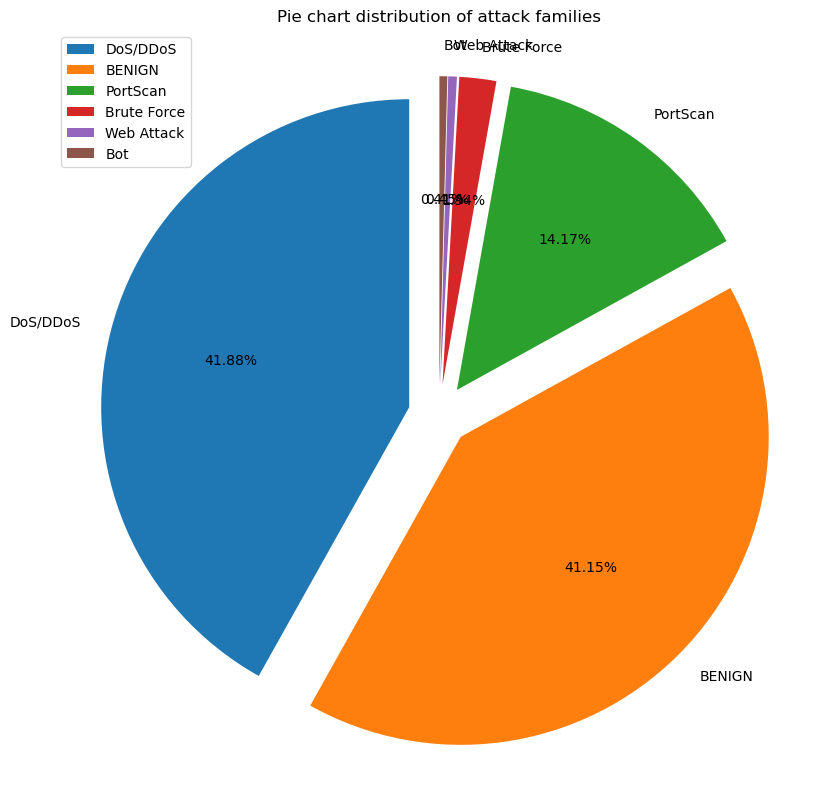

In [31]:
# 대분류별 개수 계산

family_counts = df['AttackFamily'].value_counts()


# 파이차트
plt.figure(figsize=(10, 10))
explode = [0.1] * len(family_counts)

plt.pie(
    family_counts,
    labels=family_counts.index,
    autopct='%1.2f%%',
    startangle=90,
    explode=explode
)

plt.title("Pie chart distribution of attack families")
plt.legend(family_counts.index, loc="best")
plt.show()

In [158]:
# 특징/타겟 분리
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

feature_cols = [c for c in df.columns if c not in ['Label', 'AttackFamily']]
X = df[feature_cols]
y_family = df['AttackFamily']

In [160]:
#대분류 모델
X_train, X_test, y_train, y_test = train_test_split(
    X, y_family, test_size=0.2, random_state=42, stratify=y_family
)

family_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
family_model.fit(X_train, y_train)

pred_family = family_model.predict(X_test)
print(classification_report(y_test, pred_family))

joblib.dump(family_model, 'family_model.joblib')

joblib.dump(feature_cols, 'feature_cols.joblib')

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     38877
         Bot       0.99      0.98      0.98       389
 Brute Force       1.00      1.00      1.00      1830
    DoS/DDoS       1.00      1.00      1.00     39561
    PortScan       1.00      1.00      1.00     13385
  Web Attack       0.99      0.99      0.99       429

    accuracy                           1.00     94471
   macro avg       1.00      0.99      1.00     94471
weighted avg       1.00      1.00      1.00     94471



['feature_cols.joblib']

In [161]:

# 숫자형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns

# AttackFamily + 숫자형 컬럼만 남기기
group_mean = df.groupby('AttackFamily')[numeric_cols].mean()

print(group_mean.shape)
group_mean.head()

(6, 78)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
AttackFamily,,,,,,,,,,,,,,,,,,,,,
BENIGN,10986.165429,1.072702e+07,10.032266,11.093031,533.920128,16405.878217,196.058019,20.333172,51.504780,59.036203,...,6.961453,-3857.481439,71872.160182,44364.355131,150680.605188,46203.047529,3.571851e+06,2.084248e+05,3.733640e+06,3.376841e+06
Bot,17859.005647,3.541854e+05,3.214066,3.365503,2669.837782,64.334189,408.885010,2.211499,114.266794,121.865318,...,1.703285,22.036961,63.392129,22.455725,106.187372,52.237166,1.036961e+04,2.440967e+01,1.036961e+04,1.031699e+04
Brute Force,21.358251,7.891160e+06,11.207978,17.072896,699.030055,972.495301,220.708197,0.012896,37.462950,51.647447,...,7.766995,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
DoS/DDoS,80.466853,4.222633e+07,5.367194,4.071238,216.486853,8066.999110,149.764483,2.357507,33.391230,61.349705,...,2.536842,23.772177,258529.468946,54146.458886,296677.973251,219334.659550,3.733243e+07,3.060647e+06,3.974160e+07,3.513646e+07
PortScan,8603.667698,1.170895e+05,1.026732,1.007262,1.119793,15.262029,1.105433,0.991274,1.021164,0.056862,...,0.005962,31.995039,99.182720,2.850189,103.199585,95.368657,1.119944e+05,1.414152e+02,1.123097e+05,1.119361e+05


In [162]:
def compare_with_benign(group_mean, label_name, top_n=10):
    
    print("=" * 60)
    print(f" BENIGN vs {label_name}")
    print("=" * 60)
    
    # 차이 계산
    diff = (group_mean.loc[label_name] - group_mean.loc['BENIGN']).abs()
    
    # 정렬
    diff = diff.sort_values(ascending=False)
    
    # 상위 feature
    top_features = diff.head(top_n)
    
    print(top_features)
    
    return top_features

In [163]:
labels = group_mean.index.tolist()

for label in labels:
    if label == 'BENIGN':
        continue
    
    compare_with_benign(group_mean, label)

 BENIGN vs Bot
Flow Duration    1.037284e+07
Fwd IAT Total    1.007871e+07
Bwd IAT Total    9.066993e+06
Flow IAT Max     4.284398e+06
Fwd IAT Max      4.124966e+06
Idle Max         3.723271e+06
Idle Mean        3.561481e+06
Idle Min         3.366524e+06
Bwd IAT Max      3.298081e+06
Fwd IAT Mean     2.020707e+06
dtype: float64
 BENIGN vs Brute Force
Fwd IAT Total    4.498228e+06
Idle Max         3.733640e+06
Idle Mean        3.571851e+06
Idle Min         3.376841e+06
Flow Duration    2.835862e+06
Flow IAT Max     2.246341e+06
Fwd IAT Max      2.124684e+06
Fwd IAT Mean     1.673252e+06
Bwd IAT Total    1.530701e+06
Fwd IAT Min      1.496300e+06
dtype: float64
 BENIGN vs DoS/DDoS
Idle Max         3.600796e+07
Flow IAT Max     3.582387e+07
Fwd IAT Max      3.579339e+07
Idle Mean        3.376058e+07
Idle Min         3.175962e+07
Flow Duration    3.149931e+07
Fwd IAT Total    3.135913e+07
Fwd IAT Std      1.484182e+07
Flow IAT Std     1.050002e+07
Bwd IAT Max      8.254851e+06
dtype: float

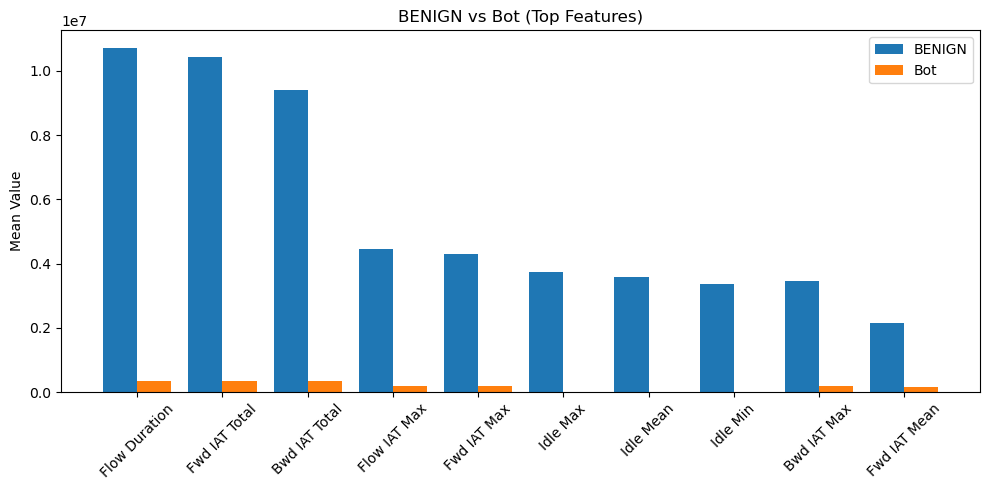

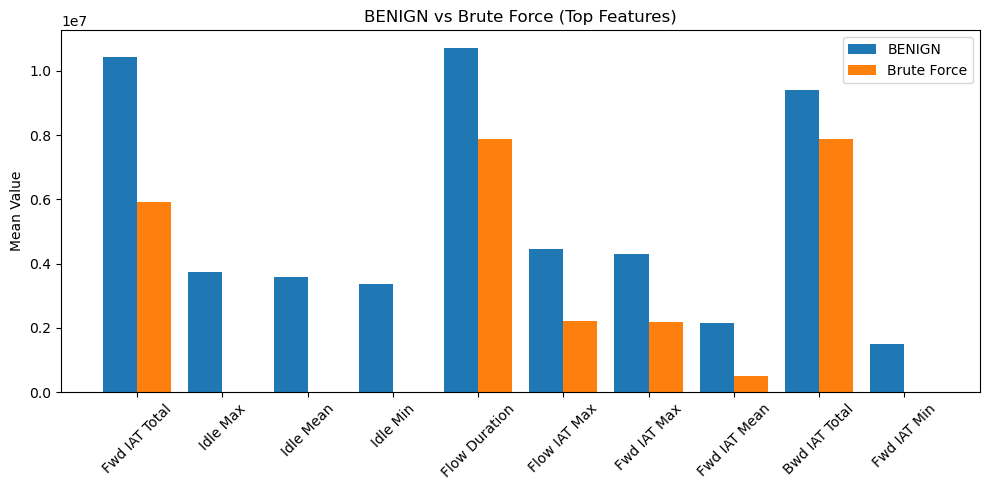

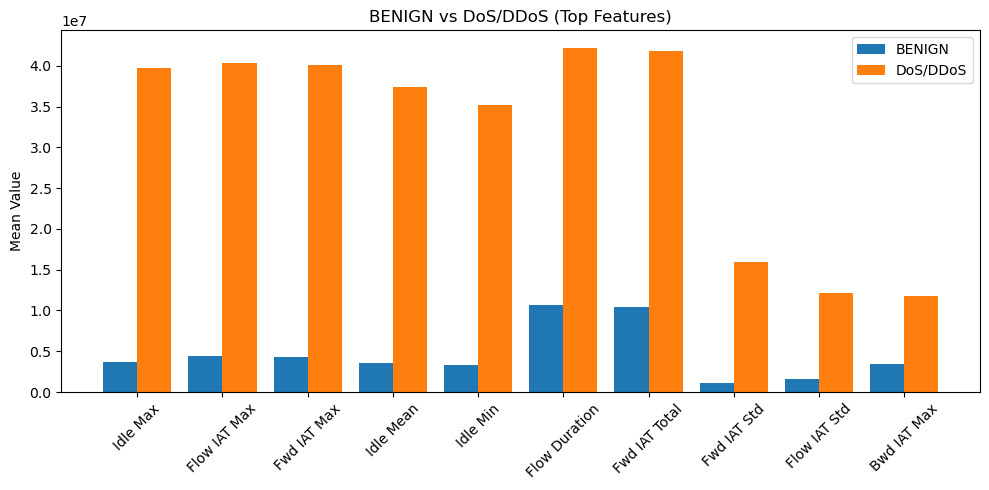

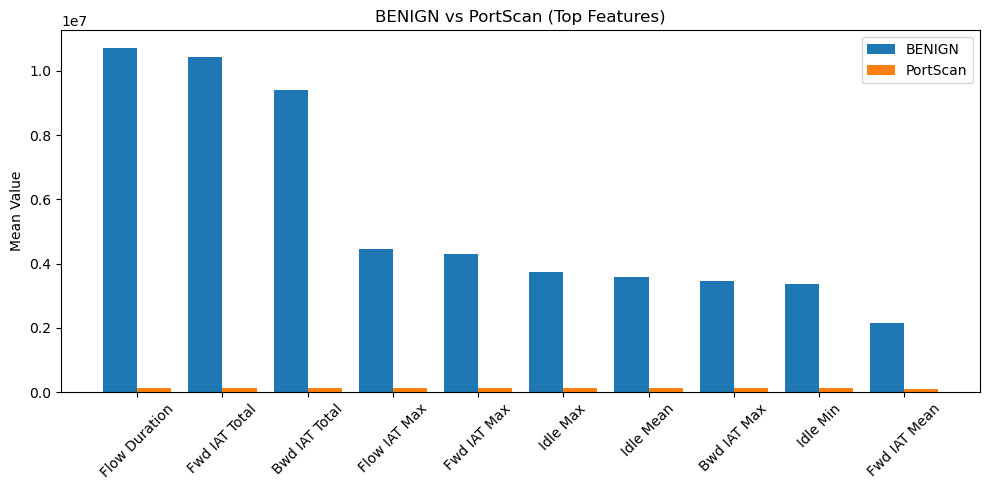

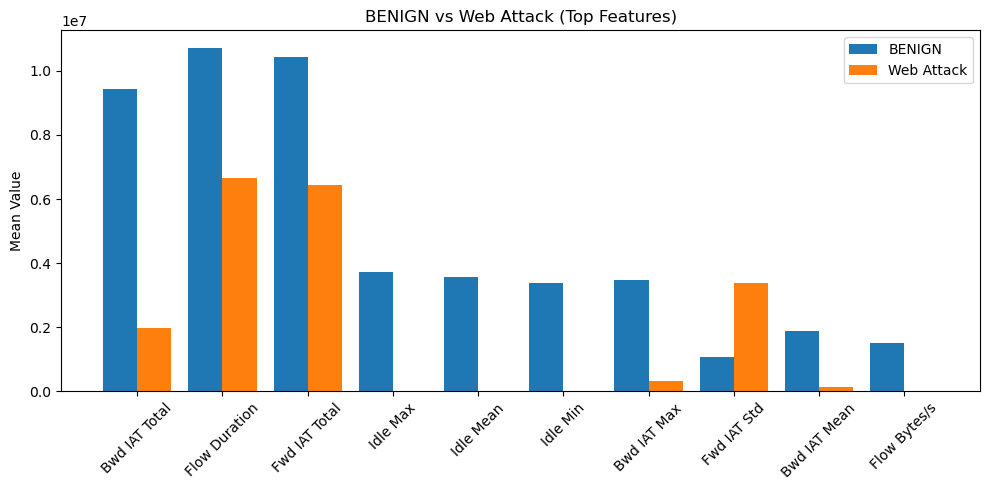

In [170]:
# AttackFamily 기준 평균
group_mean = df.groupby('AttackFamily')[feature_cols].mean()

labels = group_mean.index.tolist()

for label in labels:
    if label == 'BENIGN':
        continue

    # BENIGN과 현재 공격군의 차이 계산
    diff = (group_mean.loc[label] - group_mean.loc['BENIGN']).abs()
    diff = diff.sort_values(ascending=False)

    # 상위 10개 feature 선택
    top_features = diff.head(10).index

    # BENIGN과 공격군의 평균값
    benign_values = group_mean.loc['BENIGN'][top_features]
    attack_values = group_mean.loc[label][top_features]

    x = np.arange(len(top_features))

    plt.figure(figsize=(10, 5))

    # bar 그래프
    plt.bar(x - 0.2, benign_values, width=0.4, label='BENIGN')
    plt.bar(x + 0.2, attack_values, width=0.4, label=label)

    plt.xticks(x, top_features, rotation=45)
    plt.ylabel("Mean Value")
    plt.title(f"BENIGN vs {label} (Top Features)")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [67]:
#디도스 세부 모델
df_dos = df[df['AttackFamily'] == 'DoS/DDoS'].copy()
X_dos = df_dos[feature_cols]
y_dos = df_dos['Label']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dos, y_dos, test_size=0.2, random_state=42, stratify=y_dos
)

dos_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
dos_model.fit(X_train_d, y_train_d)

pred_dos = dos_model.predict(X_test_d)
print(classification_report(y_test_d, pred_dos))

joblib.dump(dos_model, 'dos_model.joblib')

                  precision    recall  f1-score   support

            DDoS       1.00      1.00      1.00     20165
   DoS GoldenEye       1.00      1.00      1.00      2057
        DoS Hulk       1.00      1.00      1.00     15216
DoS Slowhttptest       1.00      1.00      1.00      1046
   DoS slowloris       1.00      0.99      0.99      1077

        accuracy                           1.00     39561
       macro avg       1.00      1.00      1.00     39561
    weighted avg       1.00      1.00      1.00     39561



In [72]:
import itertools
group_mean_dos = df_dos.groupby('Label')[feature_cols].mean()

labels = group_mean_dos.index.tolist()

for label1, label2 in itertools.combinations(labels, 2):
    
    print("=" * 70)
    print(f"{label1} vs {label2}")
    print("=" * 70)
    
    diff = (group_mean_dos.loc[label1] - group_mean_dos.loc[label2]).abs()
    diff = diff.sort_values(ascending=False)
    
    print(diff.head(10))

DDoS vs DoS GoldenEye
Fwd IAT Min      1.484981e+07
Fwd IAT Mean     1.296558e+07
Flow IAT Mean    1.193390e+07
Flow IAT Min     1.130149e+07
Idle Min         9.868226e+06
Bwd IAT Total    7.606198e+06
Idle Mean        6.769619e+06
Flow Duration    6.219396e+06
Bwd IAT Max      4.410103e+06
Idle Std         4.393278e+06
dtype: float64
DDoS vs DoS Hulk
Idle Min         6.485648e+07
Idle Mean        6.249470e+07
Idle Max         6.013222e+07
Fwd IAT Max      5.976756e+07
Flow IAT Max     5.947172e+07
Fwd IAT Total    5.922776e+07
Flow Duration    5.888465e+07
Fwd IAT Std      2.525000e+07
Bwd IAT Total    2.402764e+07
Bwd IAT Max      2.397634e+07
dtype: float64
DDoS vs DoS Slowhttptest
Fwd IAT Total    4.417766e+07
Flow Duration    4.376710e+07
Fwd IAT Max      2.553194e+07
Flow IAT Max     2.525117e+07
Idle Max         2.417533e+07
Bwd IAT Total    2.323959e+07
Bwd IAT Max      2.238517e+07
Idle Mean        1.908402e+07
Idle Min         1.604187e+07
Bwd IAT Std      1.491605e+07
dtype:

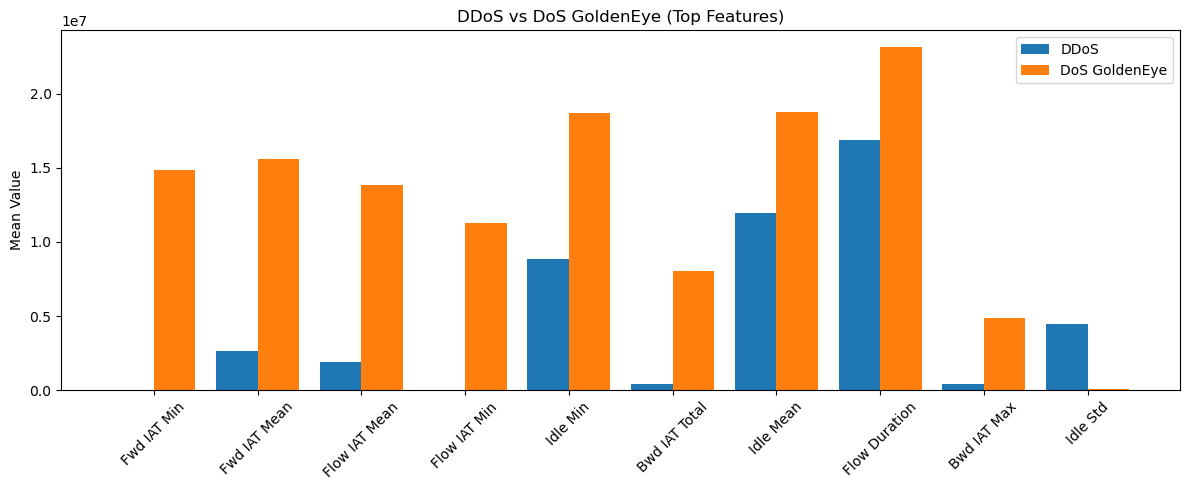

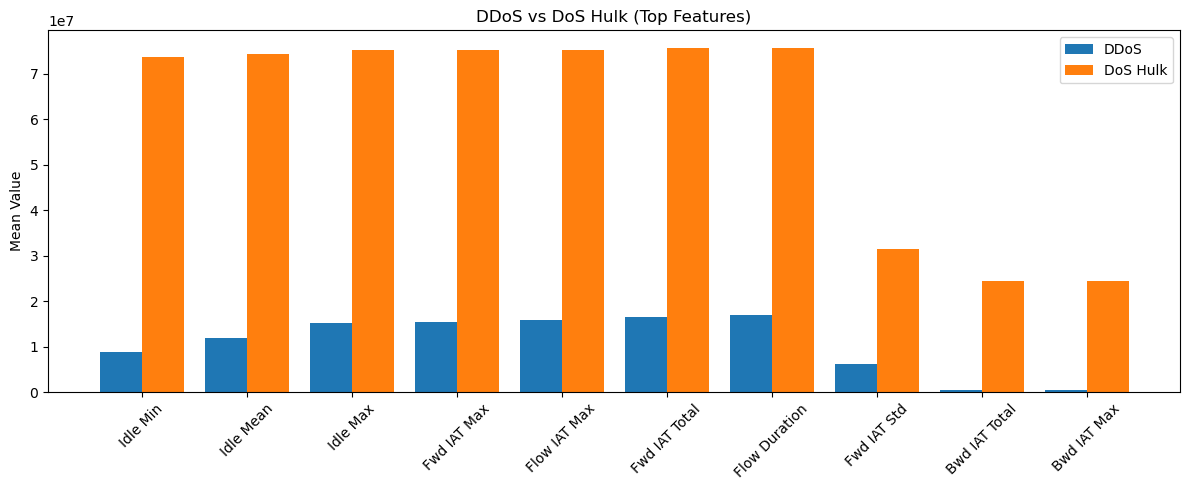

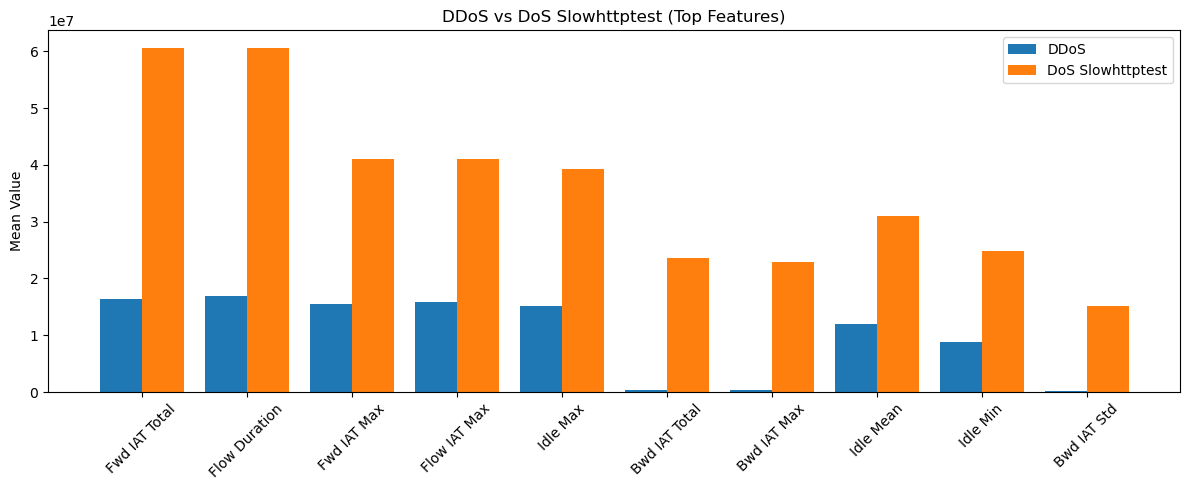

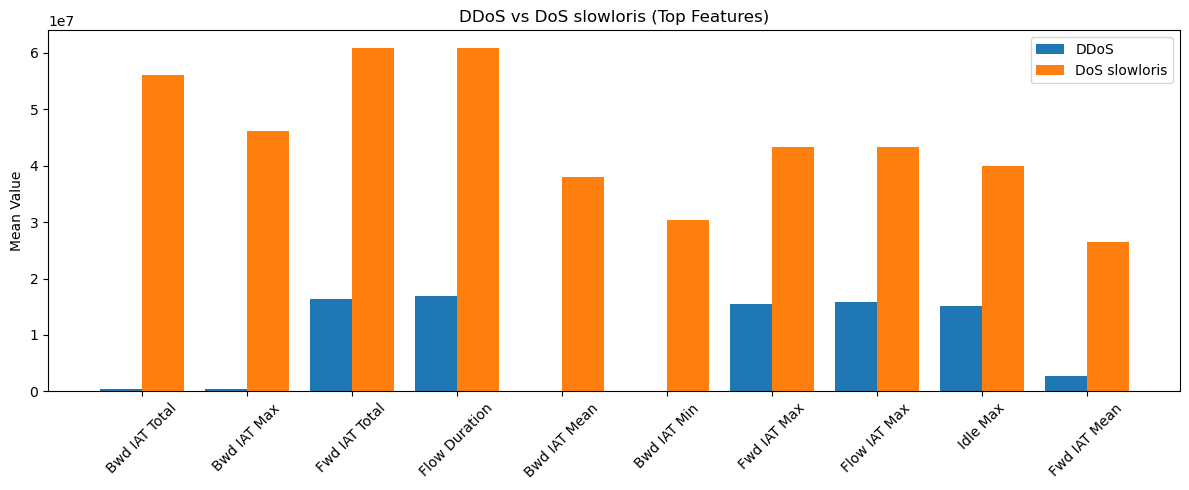

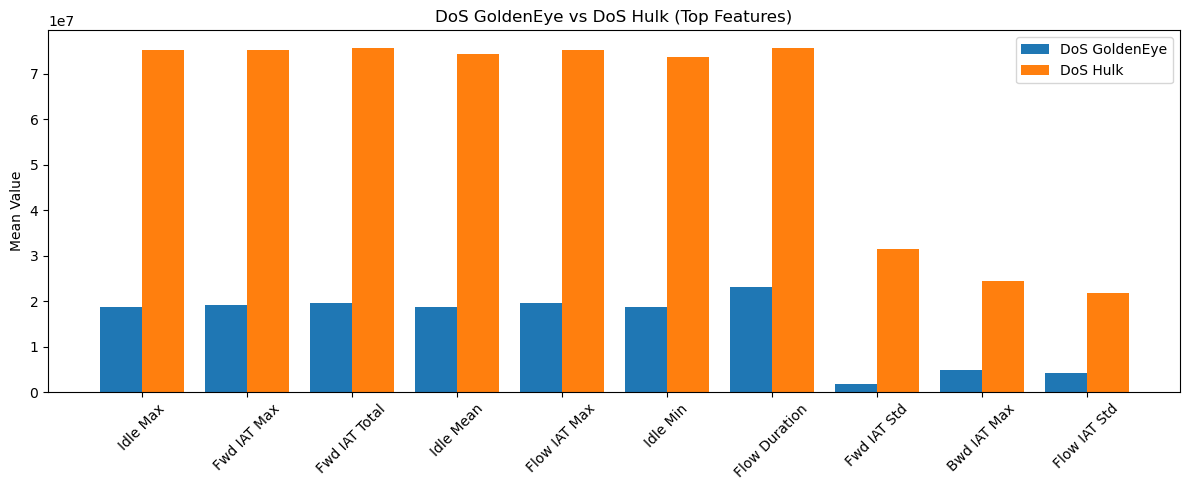

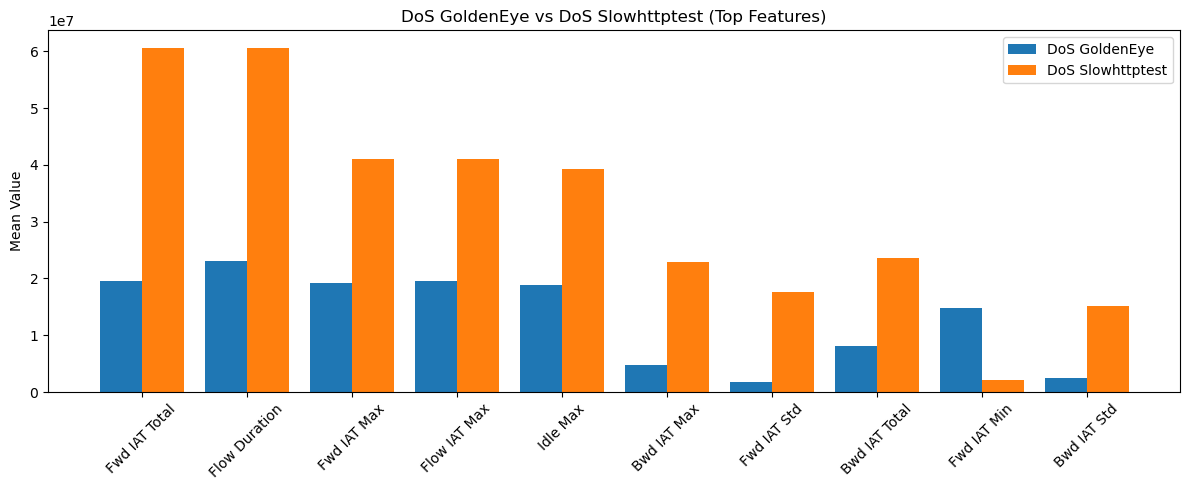

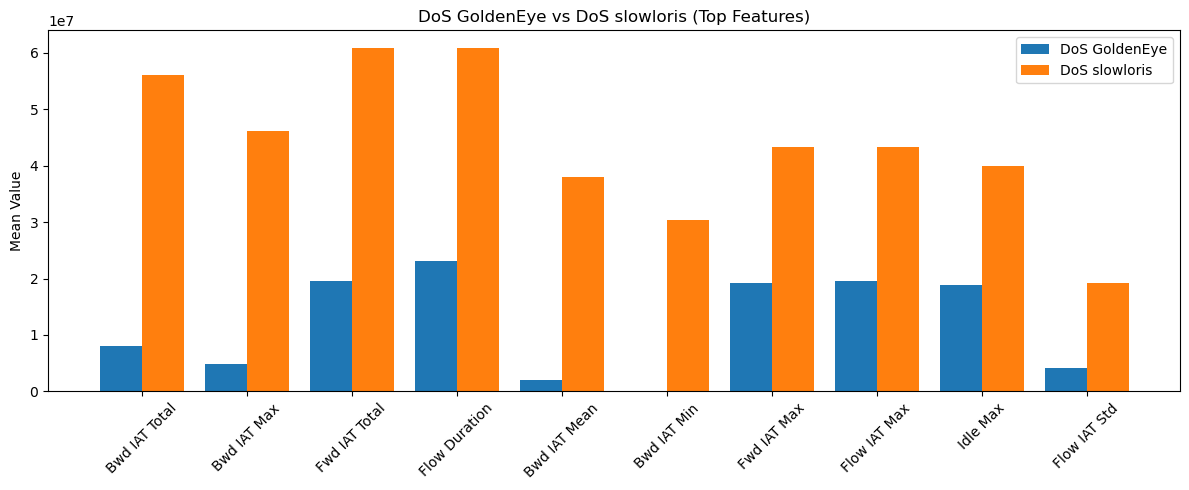

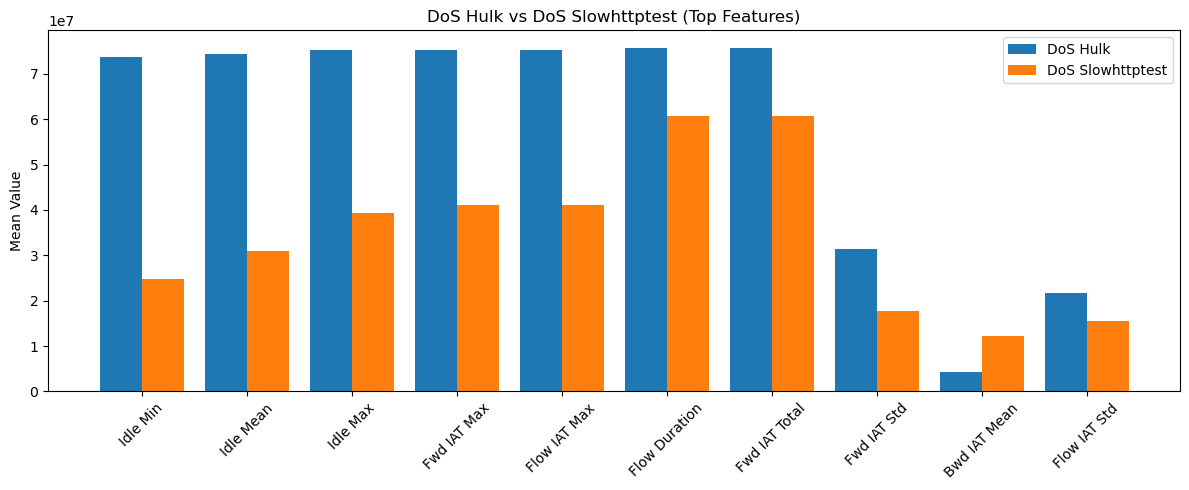

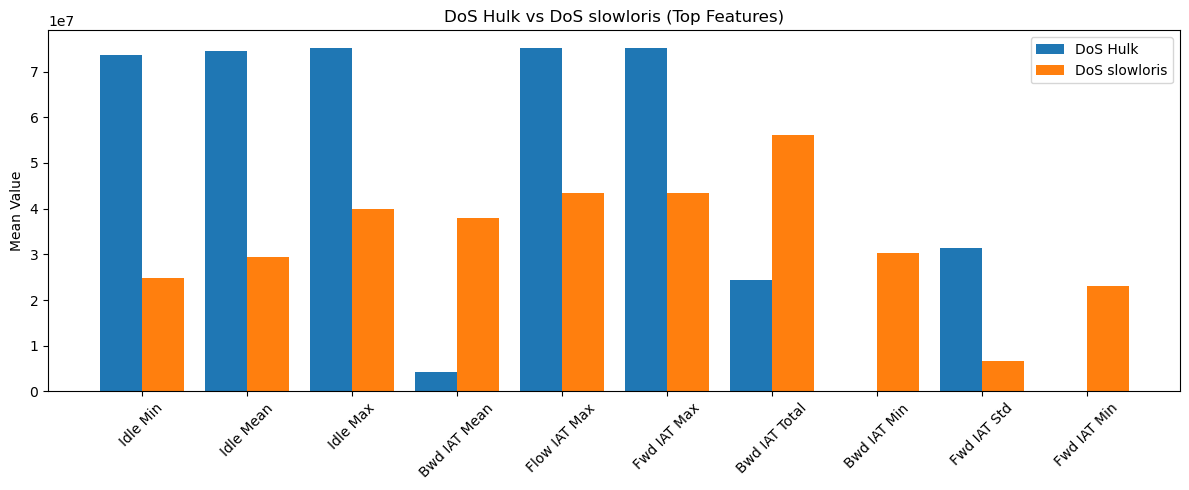

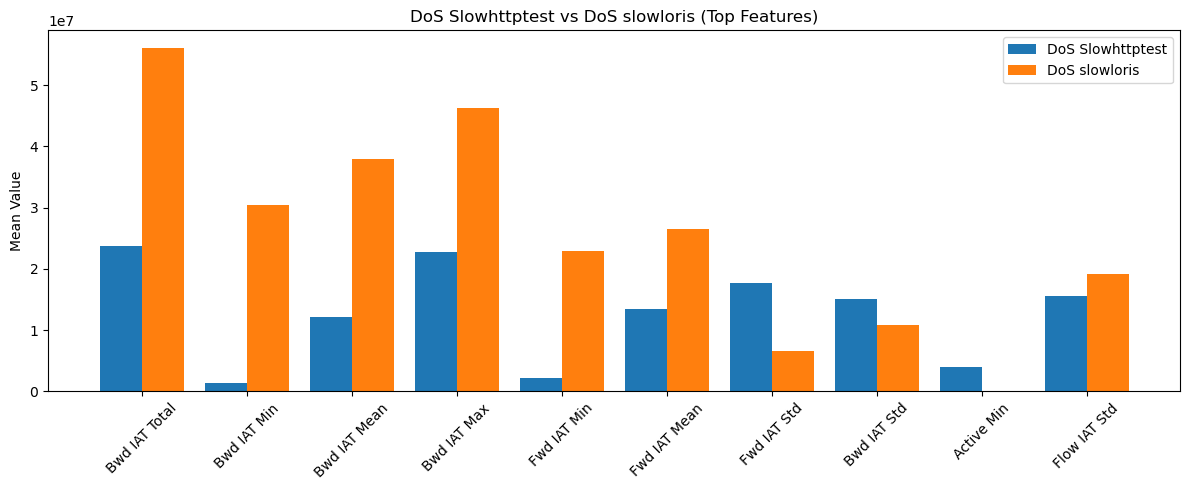

In [82]:
labels = group_mean_dos.index.tolist()

for label1, label2 in itertools.combinations(labels, 2):
    
    # 1. 차이 계산
    diff = (group_mean_dos.loc[label1] - group_mean_dos.loc[label2]).abs()
    
    # 2. 각 pair별 top feature 선택 ⭐
    top_features = diff.sort_values(ascending=False).head(10).index
    
    # 3. 값 추출
    vals1 = group_mean_dos.loc[label1][top_features]
    vals2 = group_mean_dos.loc[label2][top_features]
    
    x = np.arange(len(top_features))
    
    # 4. 그래프
    plt.figure(figsize=(12, 5))
    plt.bar(x - 0.2, vals1, width=0.4, label=label1)
    plt.bar(x + 0.2, vals2, width=0.4, label=label2)
    
    plt.xticks(x, top_features, rotation=45)
    plt.title(f"{label1} vs {label2} (Top Features)")
    plt.ylabel("Mean Value")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

In [55]:
#brute force 세부 모델
df_brute = df[df['AttackFamily'] == 'Brute Force'].copy()
X_brute = df_brute[feature_cols]
y_brute = df_brute['Label']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_brute, y_brute, test_size=0.2, random_state=42, stratify=y_brute
)

brute_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
brute_model.fit(X_train_b, y_train_b)

pred_brute = brute_model.predict(X_test_b)
print(classification_report(y_test_b, pred_brute))

joblib.dump(brute_model, 'brute_model.joblib')

              precision    recall  f1-score   support

 FTP-Patator       1.00      1.00      1.00      1186
 SSH-Patator       1.00      1.00      1.00       644

    accuracy                           1.00      1830
   macro avg       1.00      1.00      1.00      1830
weighted avg       1.00      1.00      1.00      1830



In [61]:
group_mean_brute = df_brute.groupby('Label')[feature_cols].mean()

labels = group_mean_brute.index.tolist()

if len(labels) == 2:
    label1, label2 = labels[0], labels[1]
    
    diff = (group_mean_brute.loc[label1] - group_mean_brute.loc[label2]).abs()
    diff = diff.sort_values(ascending=False)
    
    print("=" * 60)
    print(f"{label1} vs {label2}")
    print("=" * 60)
    print(diff.head(10))

FTP-Patator vs SSH-Patator
Fwd IAT Total    5.385876e+06
Flow Duration    5.260637e+06
Bwd IAT Total    5.260001e+06
Fwd IAT Std      1.017123e+05
Bwd IAT Std      1.004964e+05
Flow IAT Std     8.743367e+04
Fwd IAT Max      8.243117e+04
Bwd IAT Max      8.209915e+04
Flow IAT Max     8.132131e+04
Bwd IAT Mean     6.535310e+04
dtype: float64


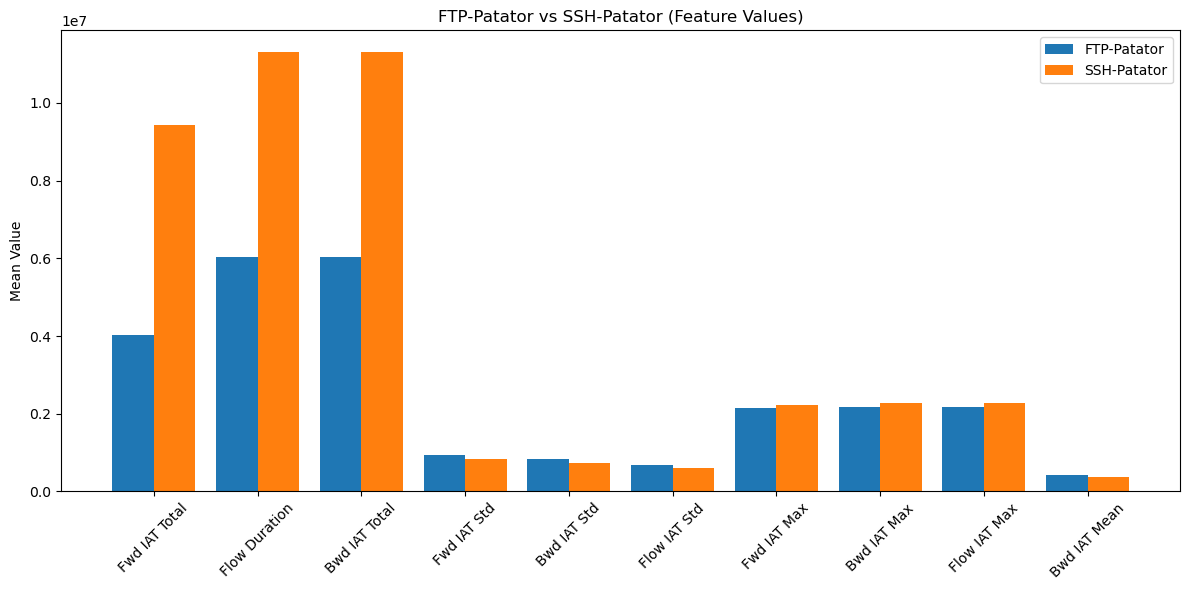

In [65]:
top_features = diff.head(10).index

vals1 = group_mean_brute.loc[label1][top_features]
vals2 = group_mean_brute.loc[label2][top_features]

import numpy as np

x = np.arange(len(top_features))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, vals1, width=0.4, label=label1)
plt.bar(x + 0.2, vals2, width=0.4, label=label2)

plt.xticks(x, top_features, rotation=45)
plt.title(f"{label1} vs {label2} (Feature Values)")
plt.ylabel("Mean Value")

plt.legend()
plt.tight_layout()
plt.show()

In [148]:
# =========================================================
# 1. 라이브러리 import
# =========================================================
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# =========================================================
# 2. Web Attack 데이터만 분리
# =========================================================
# df : 전체 데이터프레임
# AttackFamily : 대분류 라벨
# Label : 원래 세부 라벨
# feature_cols : 모델에 사용할 feature 리스트

df_web = df[df['AttackFamily'] == 'Web Attack'].copy()

print("===== Web Attack 전체 라벨 분포 =====")
print(df_web['Label'].value_counts())
print()


# =========================================================
# 3. payload 컬럼 확인
# =========================================================
# 현재 데이터에 웹 요청 내용(payload, URL 등)이 있는지 확인
payload_candidates = [
    'Payload', 'payload', 'URL', 'Url', 'Request', 'request',
    'content', 'Content', 'query', 'Query'
]

payload_col = None
for c in payload_candidates:
    if c in df_web.columns:
        payload_col = c
        break

print("payload_col =", payload_col)
print()


# =========================================================
# 4. 현재 데이터 기준 모델 전략
# =========================================================
# SQL Injection은 샘플 수가 매우 적고,
# payload 정보가 없어서 현재 데이터로는 학습/탐지가 어렵다.
# 따라서 ML 모델은 Brute Force vs XSS만 학습한다.

df_web_ml = df_web[df_web['Label'] != 'Web Attack - Sql Injection'].copy()

print("===== Web Attack ML 학습용 라벨 분포 (SQL 제외) =====")
print(df_web_ml['Label'].value_counts())
print()


# =========================================================
# 5. feature / target 분리
# =========================================================
X_web = df_web_ml[feature_cols]
y_web = df_web_ml['Label']


# =========================================================
# 6. train / test split
# =========================================================
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_web,
    y_web,
    test_size=0.2,
    random_state=42,
    stratify=y_web
)


# =========================================================
# 7. Random Forest 웹 세부모델 학습
# =========================================================
web_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

web_model.fit(X_train_w, y_train_w)


# =========================================================
# 8. 평가
# =========================================================
pred_web = web_model.predict(X_test_w)

print("===== Web Attack Detail Model (Brute Force vs XSS) =====")
print("Accuracy:", accuracy_score(y_test_w, pred_web))
print()
print(classification_report(y_test_w, pred_web, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test_w, pred_web))
print()


# =========================================================
# 9. 모델 저장
# =========================================================
joblib.dump(web_model, 'web_attack_detail_model.joblib')
print("웹 세부모델 저장 완료: web_attack_detail_model.joblib")
print()


# =========================================================
# 10. 예측 함수
# =========================================================
def predict_web_attack_detail(feature_input: pd.DataFrame):
    """
    Web Attack 세부모델 예측 함수
    현재 데이터셋 기준:
    - Brute Force vs XSS만 예측 가능
    - SQL Injection은 현재 구조로 분류 불가

    feature_input:
        feature_cols와 같은 컬럼 순서의 DataFrame (1행 또는 여러 행 가능)
    """
    pred = web_model.predict(feature_input)
    return pred


# =========================================================
# 11. 테스트 예시
# =========================================================
sample_web = X_test_w.iloc[[0]]
sample_pred = predict_web_attack_detail(sample_web)

print("===== 샘플 예측 =====")
print("실제 라벨:", y_test_w.iloc[0])
print("예측 라벨:", sample_pred[0])
print()


# =========================================================
# 12. 오분류 샘플 확인
# =========================================================
web_result_df = X_test_w.copy()
web_result_df['True_Label'] = y_test_w.values
web_result_df['Pred_Label'] = pred_web

wrong_web = web_result_df[web_result_df['True_Label'] != web_result_df['Pred_Label']]

print("===== 오분류 샘플 개수 =====")
print(len(wrong_web))
print()

print("===== 오분류 샘플 일부 =====")
print(wrong_web[['True_Label', 'Pred_Label']].head(10))
print()


# =========================================================
# 13. SQL Injection은 별도 확인
# =========================================================
sql_rows = df_web[df_web['Label'] == 'Web Attack - Sql Injection'].copy()

print("===== SQL Injection 샘플 수 =====")
print(len(sql_rows))
print()

print("===== SQL Injection 샘플 라벨 확인 =====")
print(sql_rows[['Label']].head())
print()

if payload_col is None:
    print("※ 현재 데이터셋에는 payload 컬럼이 없어 SQL Injection 룰 기반 탐지를 적용할 수 없습니다.")
    print("※ 따라서 SQL Injection은 모델 학습 대상이 아니라 '분석용/한계 설명용'으로 처리합니다.")

===== Web Attack 전체 라벨 분포 =====
Label
Web Attack - Brute Force      1470
Web Attack - XSS               652
Web Attack - Sql Injection      21
Name: count, dtype: int64

payload_col = None

===== Web Attack ML 학습용 라벨 분포 (SQL 제외) =====
Label
Web Attack - Brute Force    1470
Web Attack - XSS             652
Name: count, dtype: int64

===== Web Attack Detail Model (Brute Force vs XSS) =====
Accuracy: 0.691764705882353

                          precision    recall  f1-score   support

Web Attack - Brute Force       0.75      0.82      0.79       294
        Web Attack - XSS       0.50      0.40      0.44       131

                accuracy                           0.69       425
               macro avg       0.63      0.61      0.61       425
            weighted avg       0.68      0.69      0.68       425

Confusion Matrix:
[[242  52]
 [ 79  52]]

웹 세부모델 저장 완료: web_attack_detail_model.joblib

===== 샘플 예측 =====
실제 라벨: Web Attack - Brute Force
예측 라벨: Web Attack - Brute Force

===== 오분류 

In [150]:
group_mean_web = df_web_2.groupby('Label')[feature_cols].mean()

labels = group_mean_web.index.tolist()

label1, label2 = labels[0], labels[1]

diff = (group_mean_web.loc[label1] - group_mean_web.loc[label2]).abs()
diff = diff.sort_values(ascending=False)

print(diff.head(10))

Bwd IAT Total    414909.033943
Fwd IAT Max      257080.036386
Fwd IAT Total    247853.980675
Flow IAT Max     239056.197623
Bwd IAT Max      222499.852999
Fwd IAT Std      214440.244841
Fwd IAT Mean     169755.805614
Flow IAT Std     166869.833264
Bwd IAT Mean     135132.367862
Bwd IAT Std      122312.880827
dtype: float64


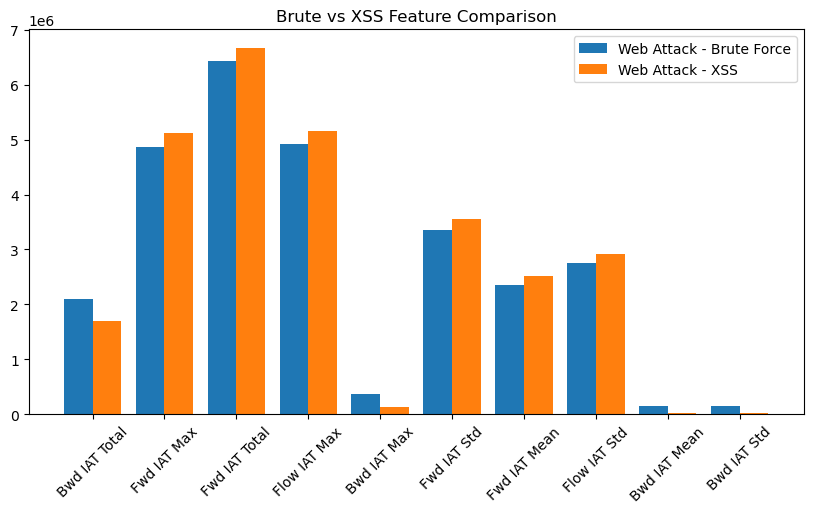

In [152]:
top_features = diff.head(10).index

vals1 = group_mean_web.loc[label1][top_features]
vals2 = group_mean_web.loc[label2][top_features]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(top_features))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, vals1, width=0.4, label=label1)
plt.bar(x + 0.2, vals2, width=0.4, label=label2)

plt.xticks(x, top_features, rotation=45)
plt.legend()
plt.title("Brute vs XSS Feature Comparison")
plt.show()

In [51]:
# 1. 모델 불러오기
model = joblib.load("RandomForest_All.joblib")
# 2. flow 데이터 불러오기
df = pd.read_csv(
    r"E:\CICFlowMeter-4.0\bin\data\daily\test1.csv",
    encoding="cp949"
)



# 3. 필요 없는 컬럼 제거 (중요)
#flow는 IP와 포트 정보를 기반으로 이미 생성된 상태이며, 모델은 해당 flow의 통계적 특징을 이용해 공격 여부를 판단한다.
drop_cols = ["Flow ID", "Src IP", "Src Port", "Dst IP", "Protocol", "Timestamp", "Label"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# 4. 학습할 때 사용한 feature 리스트 (여기에 네 feature 넣어야 함)
feature_cols = [
    "Destination Port","Flow Duration","Total Fwd Packets","Total Backward Packets",
    "Total Length of Fwd Packets","Total Length of Bwd Packets","Fwd Packet Length Max",
    "Fwd Packet Length Min","Fwd Packet Length Mean","Fwd Packet Length Std",
    "Bwd Packet Length Max","Bwd Packet Length Min","Bwd Packet Length Mean",
    "Bwd Packet Length Std","Flow Bytes/s","Flow Packets/s","Flow IAT Mean",
    "Flow IAT Std","Flow IAT Max","Flow IAT Min","Fwd IAT Total","Fwd IAT Mean",
    "Fwd IAT Std","Fwd IAT Max","Fwd IAT Min","Bwd IAT Total","Bwd IAT Mean",
    "Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags",
    "Fwd URG Flags","Bwd URG Flags","Fwd Header Length","Bwd Header Length",
    "Fwd Packets/s","Bwd Packets/s","Min Packet Length","Max Packet Length",
    "Packet Length Mean","Packet Length Std","Packet Length Variance","FIN Flag Count",
    "SYN Flag Count","RST Flag Count","PSH Flag Count","ACK Flag Count","URG Flag Count",
    "CWE Flag Count","ECE Flag Count","Down/Up Ratio","Average Packet Size",
    "Avg Fwd Segment Size","Avg Bwd Segment Size","Fwd Header Length.1",
    "Fwd Avg Bytes/Bulk","Fwd Avg Packets/Bulk","Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk","Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate",
    "Subflow Fwd Packets","Subflow Fwd Bytes","Subflow Bwd Packets","Subflow Bwd Bytes",
    "Init_Win_bytes_forward","Init_Win_bytes_backward","act_data_pkt_fwd",
    "min_seg_size_forward","Active Mean","Active Std","Active Max","Active Min",
    "Idle Mean","Idle Std","Idle Max","Idle Min"
]

# 5. 없는 컬럼 채우기
for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

# 6. 순서 맞추기
X = df[feature_cols]

# 7. NaN 처리
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# 8. 예측
pred = model.predict(X)

# 9. 결과 붙이기
df["Prediction"] = pred

# 10. 저장
df.to_csv("prediction_result.csv", index=False, encoding="utf-8-sig")

print("완료! prediction_result.csv 생성됨")

완료! prediction_result.csv 생성됨


=== 예측 결과 요약 ===
Prediction
0    76
Name: count, dtype: int64

총 Flow 수: 76
정상 Flow 수: 0
공격 Flow 수: 76

예측 결과 저장 완료: E:\CICFlowMeter-4.0\bin\data\daily\prediction_result.csv


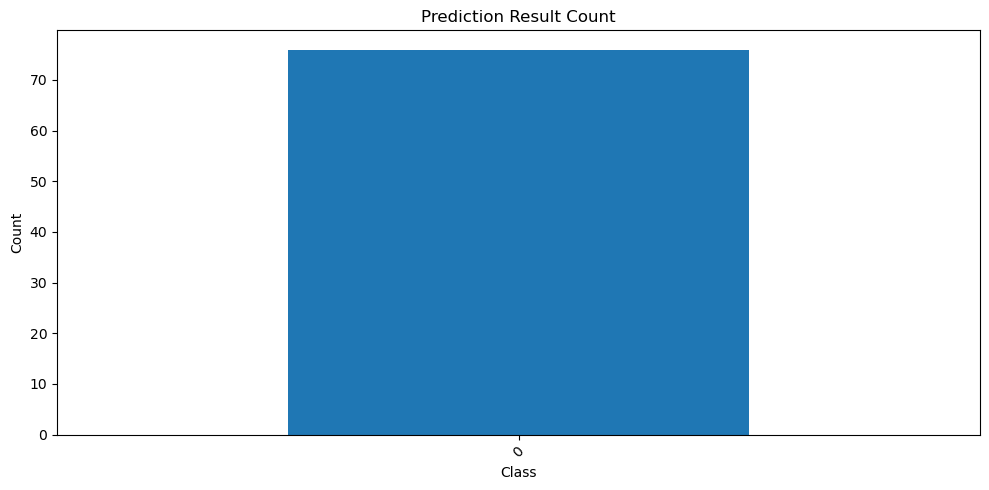

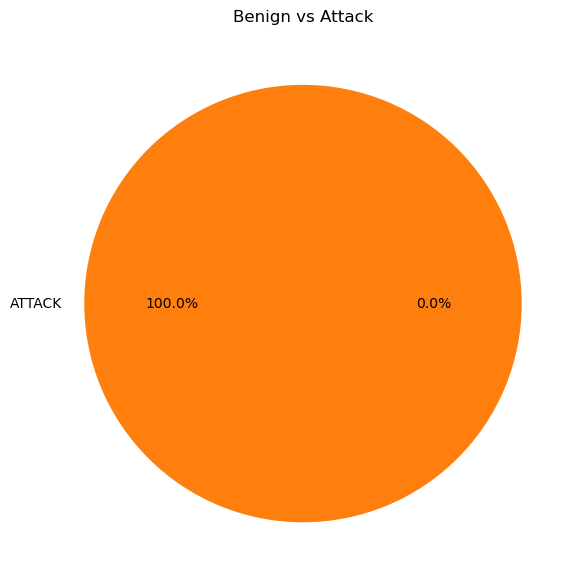

In [53]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# =========================
# 1. 모델 불러오기
# =========================
model = joblib.load("RandomForest_All.joblib")

# =========================
# 2. flow csv 불러오기
# =========================
csv_path = r"E:\CICFlowMeter-4.0\bin\data\daily\test1.csv"
df_raw = pd.read_csv(csv_path, encoding="cp949")

# 원본 보존
df = df_raw.copy()

# =========================
# 3. 컬럼명 맞추기
#    (실시간 flow csv -> train set 컬럼명)
# =========================
rename_map = {
    "Dst Port": "Destination Port",
    "Tot Fwd Pkts": "Total Fwd Packets",
    "Tot Bwd Pkts": "Total Backward Packets",
    "TotLen Fwd Pkts": "Total Length of Fwd Packets",
    "TotLen Bwd Pkts": "Total Length of Bwd Packets",
    "Fwd Pkt Len Max": "Fwd Packet Length Max",
    "Fwd Pkt Len Min": "Fwd Packet Length Min",
    "Fwd Pkt Len Mean": "Fwd Packet Length Mean",
    "Fwd Pkt Len Std": "Fwd Packet Length Std",
    "Bwd Pkt Len Max": "Bwd Packet Length Max",
    "Bwd Pkt Len Min": "Bwd Packet Length Min",
    "Bwd Pkt Len Mean": "Bwd Packet Length Mean",
    "Bwd Pkt Len Std": "Bwd Packet Length Std",
    "Flow Byts/s": "Flow Bytes/s",
    "Flow Pkts/s": "Flow Packets/s",
    "Fwd IAT Tot": "Fwd IAT Total",
    "Bwd IAT Tot": "Bwd IAT Total",
    "Fwd Header Len": "Fwd Header Length",
    "Bwd Header Len": "Bwd Header Length",
    "Pkt Len Min": "Min Packet Length",
    "Pkt Len Max": "Max Packet Length",
    "Pkt Len Mean": "Packet Length Mean",
    "Pkt Len Std": "Packet Length Std",
    "Pkt Len Var": "Packet Length Variance",
    "FIN Flag Cnt": "FIN Flag Count",
    "SYN Flag Cnt": "SYN Flag Count",
    "RST Flag Cnt": "RST Flag Count",
    "PSH Flag Cnt": "PSH Flag Count",
    "ACK Flag Cnt": "ACK Flag Count",
    "URG Flag Cnt": "URG Flag Count",
    "ECE Flag Cnt": "ECE Flag Count",
    "Pkt Size Avg": "Average Packet Size",
    "Fwd Seg Size Avg": "Avg Fwd Segment Size",
    "Bwd Seg Size Avg": "Avg Bwd Segment Size",
    "Fwd Byts/b Avg": "Fwd Avg Bytes/Bulk",
    "Fwd Pkts/b Avg": "Fwd Avg Packets/Bulk",
    "Fwd Blk Rate Avg": "Fwd Avg Bulk Rate",
    "Bwd Byts/b Avg": "Bwd Avg Bytes/Bulk",
    "Bwd Pkts/b Avg": "Bwd Avg Packets/Bulk",
    "Bwd Blk Rate Avg": "Bwd Avg Bulk Rate",
    "Subflow Fwd Pkts": "Subflow Fwd Packets",
    "Subflow Fwd Byts": "Subflow Fwd Bytes",
    "Subflow Bwd Pkts": "Subflow Bwd Packets",
    "Subflow Bwd Byts": "Subflow Bwd Bytes",
    "Init Fwd Win Byts": "Init_Win_bytes_forward",
    "Init Bwd Win Byts": "Init_Win_bytes_backward",
    "Fwd Act Data Pkts": "act_data_pkt_fwd",
    "Fwd Seg Size Min": "min_seg_size_forward",
}
df = df.rename(columns=rename_map)

# =========================
# 4. 학습에 사용한 feature 목록
# =========================
feature_cols = [
    "Destination Port","Flow Duration","Total Fwd Packets","Total Backward Packets",
    "Total Length of Fwd Packets","Total Length of Bwd Packets","Fwd Packet Length Max",
    "Fwd Packet Length Min","Fwd Packet Length Mean","Fwd Packet Length Std",
    "Bwd Packet Length Max","Bwd Packet Length Min","Bwd Packet Length Mean",
    "Bwd Packet Length Std","Flow Bytes/s","Flow Packets/s","Flow IAT Mean",
    "Flow IAT Std","Flow IAT Max","Flow IAT Min","Fwd IAT Total","Fwd IAT Mean",
    "Fwd IAT Std","Fwd IAT Max","Fwd IAT Min","Bwd IAT Total","Bwd IAT Mean",
    "Bwd IAT Std","Bwd IAT Max","Bwd IAT Min","Fwd PSH Flags","Bwd PSH Flags",
    "Fwd URG Flags","Bwd URG Flags","Fwd Header Length","Bwd Header Length",
    "Fwd Packets/s","Bwd Packets/s","Min Packet Length","Max Packet Length",
    "Packet Length Mean","Packet Length Std","Packet Length Variance","FIN Flag Count",
    "SYN Flag Count","RST Flag Count","PSH Flag Count","ACK Flag Count","URG Flag Count",
    "CWE Flag Count","ECE Flag Count","Down/Up Ratio","Average Packet Size",
    "Avg Fwd Segment Size","Avg Bwd Segment Size","Fwd Header Length.1",
    "Fwd Avg Bytes/Bulk","Fwd Avg Packets/Bulk","Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk","Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate",
    "Subflow Fwd Packets","Subflow Fwd Bytes","Subflow Bwd Packets","Subflow Bwd Bytes",
    "Init_Win_bytes_forward","Init_Win_bytes_backward","act_data_pkt_fwd",
    "min_seg_size_forward","Active Mean","Active Std","Active Max","Active Min",
    "Idle Mean","Idle Std","Idle Max","Idle Min"
]

# train set에 있었던 중복 컬럼 보정
if "Fwd Header Length.1" not in df.columns and "Fwd Header Length" in df.columns:
    df["Fwd Header Length.1"] = df["Fwd Header Length"]

# 없는 feature는 0으로 채움
for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

# 필요한 feature만 추출
X = df[feature_cols].copy()

# inf / nan 처리
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# =========================
# 5. 예측
# =========================
pred = model.predict(X)

# 결과 붙이기
df_result = df_raw.copy()
df_result["Prediction"] = pred

# =========================
# 6. 결과 요약 출력
# =========================
print("=== 예측 결과 요약 ===")
print(df_result["Prediction"].value_counts())

total = len(df_result)
attack_count = (df_result["Prediction"] != "BENIGN").sum()
benign_count = (df_result["Prediction"] == "BENIGN").sum()

print(f"\n총 Flow 수: {total}")
print(f"정상 Flow 수: {benign_count}")
print(f"공격 Flow 수: {attack_count}")

# =========================
# 7. 결과 저장
# =========================
save_path = r"E:\CICFlowMeter-4.0\bin\data\daily\prediction_result.csv"
df_result.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"\n예측 결과 저장 완료: {save_path}")

# =========================
# 8. 막대 그래프
# =========================
plt.figure(figsize=(10, 5))
df_result["Prediction"].value_counts().plot(kind="bar")
plt.title("Prediction Result Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 9. 정상 vs 공격 파이차트
# =========================
summary = pd.Series({
    "BENIGN": benign_count,
    "ATTACK": attack_count
})

plt.figure(figsize=(6, 6))
summary.plot(kind="pie", autopct="%1.1f%%")
plt.title("Benign vs Attack")
plt.ylabel("")
plt.tight_layout()
plt.show()

                    feature  importance
8    Fwd Packet Length Mean    0.044721
53     Avg Fwd Segment Size    0.041777
18             Flow IAT Max    0.040954
6     Fwd Packet Length Max    0.038604
63        Subflow Fwd Bytes    0.031923
1             Flow Duration    0.031380
37            Bwd Packets/s    0.029813
52      Average Packet Size    0.028847
67  Init_Win_bytes_backward    0.028164
23              Fwd IAT Max    0.028098


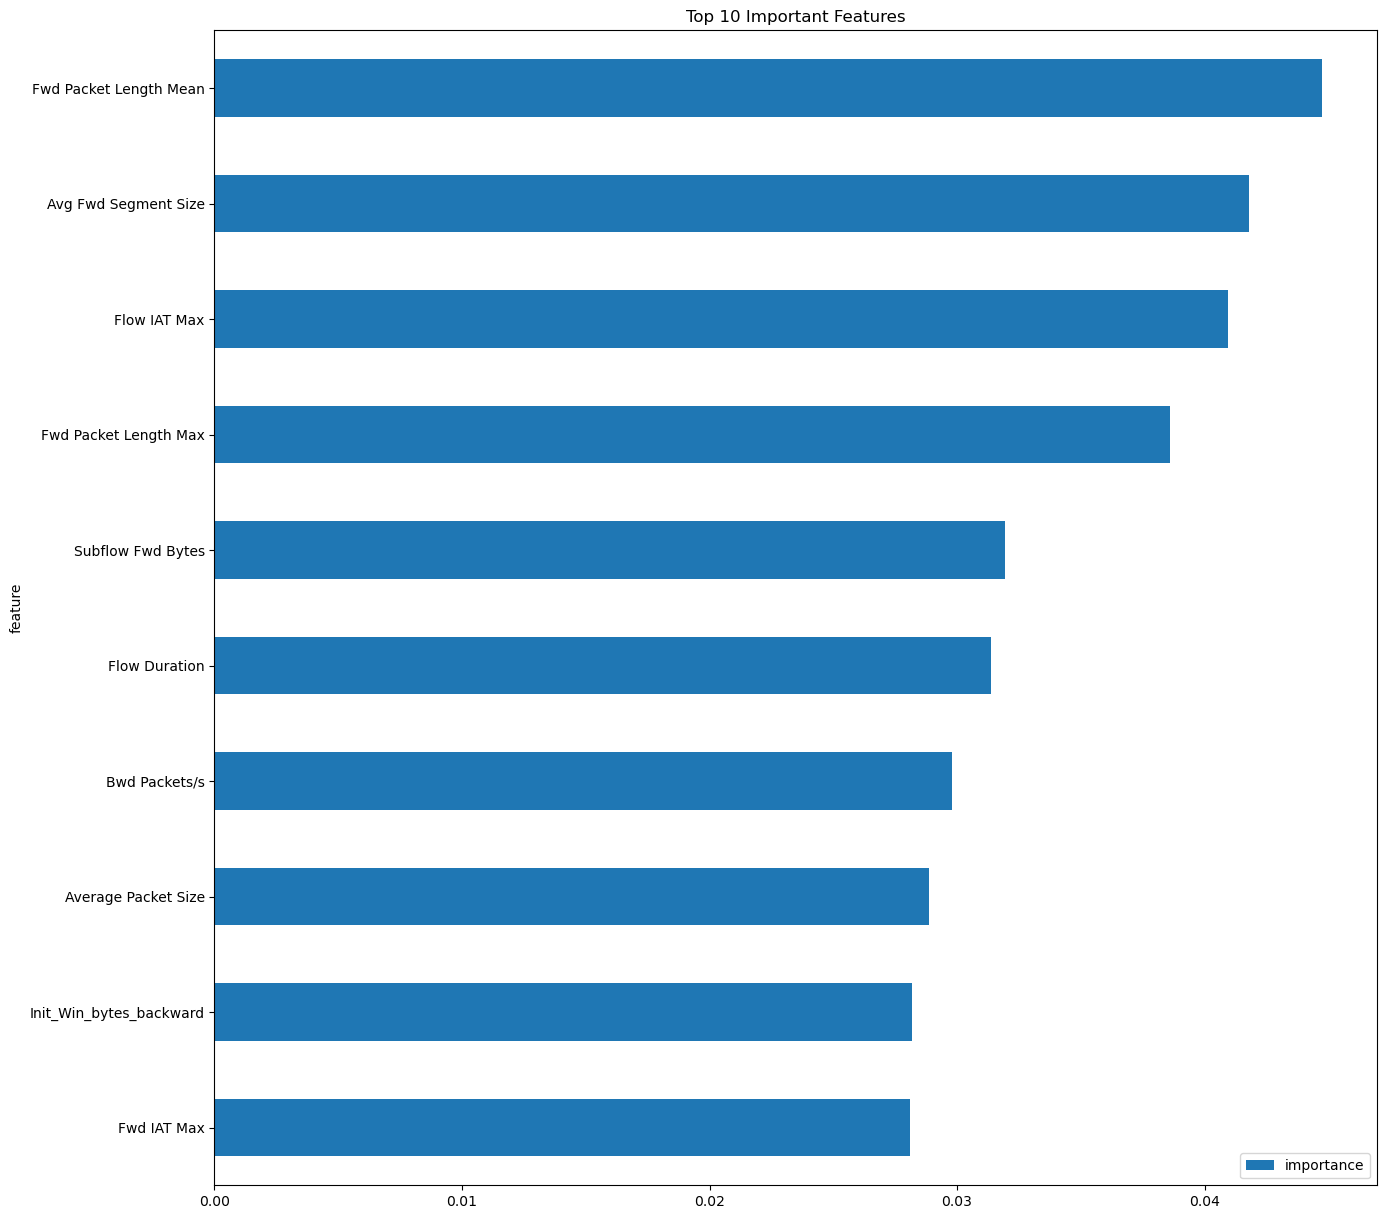

In [55]:
# 중요도 가져오기
importances = model.feature_importances_

# feature 이름
features = X.columns

# 정리
imp_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(imp_df.head(10))

# 그래프
imp_df.head(10).plot(
    kind="barh",
    x="feature",
    y="importance"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()